In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import pickle
import plotly.express as px
import streamlit as st

In [3]:
import pandas as pd

player_raw = pd.read_csv(
    "2022-2023 Football Player Stats.csv",
    encoding="latin1"
)

print(player_raw.head())

  Rk;Player;Nation;Pos;Squad;Comp;Age;Born;MP;Starts;Min;90s;Goals;Shots;SoT;SoT%;G/Sh;G/SoT;ShoDist;ShoFK;ShoPK;PKatt;PasTotCmp;PasTotAtt;PasTotCmp%;PasTotDist;PasTotPrgDist;PasShoCmp;PasShoAtt;PasShoCmp%;PasMedCmp;PasMedAtt;PasMedCmp%;PasLonCmp;PasLonAtt;PasLonCmp%;Assists;PasAss;Pas3rd;PPA;CrsPA;PasProg;PasAtt;PasLive;PasDead;PasFK;TB;Sw;PasCrs;TI;CK;CkIn;CkOut;CkStr;PasCmp;PasOff;PasBlocks;SCA;ScaPassLive;ScaPassDead;ScaDrib;ScaSh;ScaFld;ScaDef;GCA;GcaPassLive;GcaPassDead;GcaDrib;GcaSh;GcaFld;GcaDef;Tkl;TklWon;TklDef3rd;TklMid3rd;TklAtt3rd;TklDri;TklDriAtt;TklDri%;TklDriPast;Blocks;BlkSh;BlkPass;Int;Tkl+Int;Clr;Err;Touches;TouDefPen;TouDef3rd;TouMid3rd;TouAtt3rd;TouAttPen;TouLive;ToAtt;ToSuc;ToSuc%;ToTkl;ToTkl%;Carries;CarTotDist;CarPrgDist;CarProg;Car3rd;CPA;CarMis;CarDis;Rec;RecProg;CrdY;CrdR;2CrdY;Fls;Fld;Off;Crs;TklW;PKwon;PKcon;OG;Recov;AerWon;AerLost;AerWon%
0  1;Brenden Aaronson;USA;MFFW;Leeds United;Premi...                                                                   

In [4]:
pd.set_option('display.max_rows', None) # display all rows
pd.set_option('display.max_columns', None) # display all columns

player_raw.head()

,Rk;Player;Nation;Pos;Squad;Comp;Age;Born;MP;Starts;Min;90s;Goals;Shots;SoT;SoT%;G/Sh;G/SoT;ShoDist;ShoFK;ShoPK;PKatt;PasTotCmp;PasTotAtt;PasTotCmp%;PasTotDist;PasTotPrgDist;PasShoCmp;PasShoAtt;PasShoCmp%;PasMedCmp;PasMedAtt;PasMedCmp%;PasLonCmp;PasLonAtt;PasLonCmp%;Assists;PasAss;Pas3rd;PPA;CrsPA;PasProg;PasAtt;PasLive;PasDead;PasFK;TB;Sw;PasCrs;TI;CK;CkIn;CkOut;CkStr;PasCmp;PasOff;PasBlocks;SCA;ScaPassLive;ScaPassDead;ScaDrib;ScaSh;ScaFld;ScaDef;GCA;GcaPassLive;GcaPassDead;GcaDrib;GcaSh;GcaFld;GcaDef;Tkl;TklWon;TklDef3rd;TklMid3rd;TklAtt3rd;TklDri;TklDriAtt;TklDri%;TklDriPast;Blocks;BlkSh;BlkPass;Int;Tkl+Int;Clr;Err;Touches;TouDefPen;TouDef3rd;TouMid3rd;TouAtt3rd;TouAttPen;TouLive;ToAtt;ToSuc;ToSuc%;ToTkl;ToTkl%;Carries;CarTotDist;CarPrgDist;CarProg;Car3rd;CPA;CarMis;CarDis;Rec;RecProg;CrdY;CrdR;2CrdY;Fls;Fld;Off;Crs;TklW;PKwon;PKcon;OG;Recov;AerWon;AerLost;AerWon%
0,1;Brenden Aaronson;USA;MFFW;Leeds United;Premi...
1,2;Yunis Abdelhamid;MAR;DF;Reims;Ligue 1;35;198...
2,3;Himad Abdelli;FRA;MFFW;Angers;Ligue 1;23;199...
3,4;Salis Abdul Samed;GHA;MF;Lens;Ligue 1;22;200...
4,5;Laurent Abergel;FRA;MF;Lorient;Ligue 1;30;19...


In [5]:
import pandas as pd

player_raw = pd.read_csv(
    "2022-2023 Football Player Stats.csv",
    sep=";",
    encoding="latin1"
)

player_raw.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,90s,Goals,Shots,SoT,SoT%,G/Sh,G/SoT,ShoDist,ShoFK,ShoPK,PKatt,PasTotCmp,PasTotAtt,PasTotCmp%,PasTotDist,PasTotPrgDist,PasShoCmp,PasShoAtt,PasShoCmp%,PasMedCmp,PasMedAtt,PasMedCmp%,PasLonCmp,PasLonAtt,PasLonCmp%,Assists,PasAss,Pas3rd,PPA,CrsPA,PasProg,PasAtt,PasLive,PasDead,PasFK,TB,Sw,PasCrs,TI,CK,CkIn,CkOut,CkStr,PasCmp,PasOff,PasBlocks,SCA,ScaPassLive,ScaPassDead,ScaDrib,ScaSh,ScaFld,ScaDef,GCA,GcaPassLive,GcaPassDead,GcaDrib,GcaSh,GcaFld,GcaDef,Tkl,TklWon,TklDef3rd,TklMid3rd,TklAtt3rd,TklDri,TklDriAtt,TklDri%,TklDriPast,Blocks,BlkSh,BlkPass,Int,Tkl+Int,Clr,Err,Touches,TouDefPen,TouDef3rd,TouMid3rd,TouAtt3rd,TouAttPen,TouLive,ToAtt,ToSuc,ToSuc%,ToTkl,ToTkl%,Carries,CarTotDist,CarPrgDist,CarProg,Car3rd,CPA,CarMis,CarDis,Rec,RecProg,CrdY,CrdR,2CrdY,Fls,Fld,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
0,1,Brenden Aaronson,USA,MFFW,Leeds United,Premier League,22,2000,20,19,1596,17.7,1,1.53,0.28,18.5,0.04,0.20,19.0,0.11,0.0,0.0,23.2,31.0,74.9,293.0,85.7,13.3,16.2,81.9,5.93,7.74,76.6,0.90,2.37,38.1,0.11,1.75,1.75,0.45,0.11,3.22,31.0,28.1,2.88,0.96,0.17,0.00,2.54,0.23,1.47,0.68,0.62,0.06,23.2,0.00,0.85,3.62,2.37,0.56,0.23,0.11,0.28,0.06,0.28,0.17,0.0,0.0,0.06,0.0,0.06,1.64,0.51,0.45,0.90,0.28,0.51,1.47,34.6,0.96,1.69,0.11,1.58,0.06,1.69,0.28,0.06,44.0,0.40,4.35,19.0,21.50,2.49,44.0,3.73,1.19,31.8,1.75,47.0,26.7,136.1,56.6,1.53,1.07,0.40,2.60,3.11,30.2,5.65,0.11,0.0,0.0,0.62,2.26,0.17,2.54,0.51,0.0,0.0,0.00,4.86,0.34,1.19,22.2
1,2,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,35,1987,22,22,1980,22.0,0,0.86,0.05,5.3,0.00,0.00,13.5,0.00,0.0,0.0,38.5,47.2,81.5,751.5,318.5,10.9,12.9,84.5,23.20,25.70,90.1,3.77,7.00,53.9,0.05,0.27,2.91,0.09,0.00,4.50,47.2,43.3,3.73,3.32,0.00,0.55,0.18,0.09,0.00,0.00,0.00,0.00,38.5,0.23,0.59,1.14,0.86,0.00,0.00,0.18,0.00,0.09,0.18,0.14,0.0,0.0,0.05,0.0,0.00,2.50,1.59,1.45,1.00,0.05,1.32,1.68,78.4,0.36,2.23,0.77,1.45,2.00,4.50,2.91,0.05,59.2,6.23,27.50,29.5,2.73,1.09,59.2,0.68,0.32,46.7,0.36,53.3,40.0,234.2,125.0,0.55,0.23,0.09,0.73,0.68,34.5,0.23,0.09,0.0,0.0,1.32,0.50,0.05,0.18,1.59,0.0,0.0,0.00,6.64,2.18,1.23,64.0
2,3,Himad Abdelli,FRA,MFFW,Angers,Ligue 1,23,1999,14,8,770,8.6,0,1.05,0.35,33.3,0.00,0.00,19.2,0.00,0.0,0.0,40.0,49.5,80.8,676.0,188.1,18.5,22.0,84.1,15.50,18.70,82.6,4.42,5.93,74.5,0.00,1.51,3.95,1.74,0.35,6.40,49.5,48.1,1.16,0.35,0.12,0.23,1.05,0.81,0.00,0.00,0.00,0.00,40.0,0.23,1.16,2.67,2.44,0.00,0.00,0.12,0.00,0.12,0.00,0.00,0.0,0.0,0.00,0.0,0.00,2.91,1.40,1.28,1.40,0.23,1.63,2.67,60.9,1.05,1.51,0.12,1.40,0.93,3.84,0.93,0.00,62.6,0.93,11.40,36.0,17.40,1.16,62.6,3.84,2.09,54.5,1.51,39.4,48.5,298.5,151.0,2.56,2.56,0.47,2.09,1.05,43.4,5.93,0.12,0.0,0.0,1.74,1.28,0.00,1.05,1.40,0.0,0.0,0.00,8.14,0.93,1.05,47.1
3,4,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,2000,20,20,1799,20.0,1,0.60,0.15,25.0,0.08,0.33,20.3,0.00,0.0,0.0,59.5,64.9,91.6,946.3,226.9,29.6,31.8,93.2,24.70,26.20,94.3,3.35,4.30,77.9,0.00,0.50,6.00,0.55,0.10,5.60,64.9,63.1,1.40,1.30,0.05,0.20,0.35,0.10,0.00,0.00,0.00,0.00,59.5,0.35,0.40,1.60,1.35,0.00,0.10,0.10,0.00,0.05,0.00,0.00,0.0,0.0,0.00,0.0,0.00,1.50,0.80,0.55,0.85,0.10,0.85,1.30,65.4,0.45,1.30,0.35,0.95,1.10,2.60,0.80,0.00,73.3,2.10,12.00,49.6,12.20,0.70,73.3,1.25,0.70,56.0,0.40,32.0,61.0,316.9,117.5,1.25,1.95,0.15,1.35,1.30,56.5,1.70,0.15,0.0,0.0,2.45,1.35,0.00,0.35,0.80,0.0,0.0,0.05,6.60,0.50,0.50,50.0
4,5,Laurent Abergel,FRA,MF,Lorient,Ligue 1,30,1993,15,15,1165,12.9,0,0.31,0.00,0.0,0.00,0.00,23.9,0.00,0.0,0.0,37.9,43.4,87.3,613.6,224.7,17.9,19.4,92.4,15.70,17.80,88.6,2.64,3.95,66.7,0.08,0.62,3.88,0.39,0.00,5.04,43.4,42.6,0.78,0.78,0.39,0.16,0.23,0.00,0.00,0.00,0.00,0.00,37.9,0.08,0.31,1.24,1.01,0.08,0.00,0.08,0.00,0.08,0.08,0.08,0.0,0.0,0.00,0.0,0.00,3.80,2.02,2.64,1.16,0.00,1.32,3.26,40.5,1.94,1.40,0.23,1.16,1.16,4.96,1.55,0.00,54.7,3.26,19.20,31.4,4.88,0.23,54.7,0.93,0.54,58.3,0.31,33.3,41.0,174.3,72.7,0.47,0.93,0.00,1.32,0.78,36.4,0.47,0.16,0.0,0.0,0.93,1.01,0.00,0.23,2.02,0.0,0.0,0.00,6.51,0.31,0.39,44.4


In [6]:
print(player_raw.shape)
print(player_raw.columns)

(2689, 124)
Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts',
       ...
       'Off', 'Crs', 'TklW', 'PKwon', 'PKcon', 'OG', 'Recov', 'AerWon',
       'AerLost', 'AerWon%'],
      dtype='str', length=124)


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

# =========================
# LOAD DATASET
# =========================

player_raw = pd.read_csv(
    "2022-2023 Football Player Stats.csv",
    sep=";",
    encoding="latin1"
)

# Unique player names
player_list = player_raw['Player'].dropna().unique()

# =========================
# TRANSFERMARKT SEARCH URL
# =========================

base_url = "https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query="

# =========================
# STORE RESULTS
# =========================

results = []

# =========================
# USER AGENTS
# =========================

headers_list = [
    {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0 Safari/537.36"
        )
    },
    {
        "User-Agent": (
            "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/119.0 Safari/537.36"
        )
    }
]

# =========================
# CREATE SESSION
# =========================

session = requests.Session()

total_players = len(player_list)

print(f"Total Players: {total_players}")

# =========================
# SCRAPING LOOP
# =========================

for i, player in enumerate(player_list, start=1):

    print(f"\nProcessing {i}/{total_players}: {player}")

    try:

        # Create URL
        search_url = base_url + player.replace(" ", "+")

        # Random headers
        headers = random.choice(headers_list)

        # Request page
        response = session.get(
            search_url,
            headers=headers,
            timeout=15
        )

        # Check response
        if response.status_code != 200:

            print(f"Blocked/Error Status Code: {response.status_code}")

            results.append({
                "Player": player,
                "Market Value": "Blocked"
            })

            time.sleep(15)

            continue

        # Parse HTML
        soup = BeautifulSoup(response.text, "html.parser")

        # Find market value
        market_value_tag = soup.find(
            "td",
            class_="rechts hauptlink"
        )

        # Extract value
        if market_value_tag:
            market_value = market_value_tag.text.strip()
        else:
            market_value = "Not Found"

        # Save result
        results.append({
            "Player": player,
            "Market Value": market_value
        })

        print("Market Value:", market_value)

        # Save backup every 50 players
        if i % 50 == 0:

            backup_df = pd.DataFrame(results)

            backup_df.to_csv(
                "backup_market_values.csv",
                index=False
            )

            print("Backup Saved")

        # Random delay
        time.sleep(random.uniform(2, 5))

    except Exception as e:

        print("Error:", e)

        results.append({
            "Player": player,
            "Market Value": f"Error: {e}"
        })

        # Wait after errors
        time.sleep(10)

# =========================
# FINAL DATAFRAME
# =========================

df_results = pd.DataFrame(results)

# =========================
# SAVE CSV
# =========================

df_results.to_csv(
    "player_market_values.csv",
    index=False
)

print("\nScraping Completed")
print(df_results.head())

Total Players: 2530

Processing 1/2530: Brenden Aaronson
Market Value: €18.00m

Processing 2/2530: Yunis Abdelhamid
Market Value: €300k

Processing 3/2530: Himad Abdelli
Market Value: €7.00m

Processing 4/2530: Salis Abdul Samed
Market Value: €4.50m

Processing 5/2530: Laurent Abergel
Market Value: €2.00m

Processing 6/2530: Oliver Abildgaard
Market Value: €500k

Processing 7/2530: Matthis Abline
Market Value: €20.00m

Processing 8/2530: Abner
Market Value: €10.00m

Processing 9/2530: Zakaria Aboukhlal
Market Value: €7.50m

Processing 10/2530: Tammy Abraham
Market Value: €20.00m

Processing 11/2530: Francesco Acerbi
Market Value: €2.50m

Processing 12/2530: Mohamed Achi
Market Value: €150k

Processing 13/2530: Marcos Acuña
Market Value: €1.20m

Processing 14/2530: Che Adams
Market Value: €8.50m

Processing 15/2530: Tyler Adams
Market Value: €25.00m

Processing 16/2530: Sargis Adamyan
Market Value: €300k

Processing 17/2530: Tosin Adarabioyo
Market Value: €18.00m

Processing 18/2530: Ma

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

# =========================
# LOAD ORIGINAL DATASET
# =========================

player_raw = pd.read_csv(
    "2022-2023 Football Player Stats.csv",
    sep=";",
    encoding="latin1"
)

player_list = player_raw['Player'].dropna().unique()

# =========================
# LOAD BACKUP
# =========================

backup_df = pd.read_csv("backup_market_values.csv")

completed_players = backup_df["Player"].tolist()

remaining_players = [
    p for p in player_list
    if p not in completed_players
]

print("Completed:", len(completed_players))
print("Remaining:", len(remaining_players))

# =========================
# TRANSFERMARKT URL
# =========================

search_base = (
    "https://www.transfermarkt.com/"
    "schnellsuche/ergebnis/schnellsuche?query="
)

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0 Safari/537.36"
    )
}

session = requests.Session()

results = backup_df.to_dict("records")

# =========================
# CONTINUE SCRAPING
# =========================

for i, player in enumerate(remaining_players, start=1):

    try:

        search_url = search_base + player.replace(" ", "+")

        response = session.get(
            search_url,
            headers=headers,
            timeout=15
        )

        if response.status_code != 200:

            print("Blocked:", response.status_code)

            time.sleep(20)

            continue

        soup = BeautifulSoup(
            response.text,
            "html.parser"
        )

        player_link = soup.select_one(
            "td.hauptlink a"
        )

        if player_link is None:

            results.append({
                "Player": player,
                "Market Value": "Not Found"
            })

            continue

        profile_url = (
            "https://www.transfermarkt.com"
            + player_link["href"]
        )

        profile_response = session.get(
            profile_url,
            headers=headers,
            timeout=15
        )

        profile_soup = BeautifulSoup(
            profile_response.text,
            "html.parser"
        )

        market_value_tag = profile_soup.select_one(
            "div.marketValue"
        )

        if market_value_tag:
            market_value = market_value_tag.text.strip()
        else:
            market_value = "Not Found"

        results.append({
            "Player": player,
            "Market Value": market_value
        })

        # Print occasionally only
        if i % 10 == 0:
            print(f"Processed {i} remaining players")

        # Save continuously
        if i % 25 == 0:

            pd.DataFrame(results).to_csv(
                "backup_market_values.csv",
                index=False
            )

            print("Backup Saved")

        time.sleep(random.uniform(1, 1.5))

    except Exception as e:

        print("Error:", e)

        results.append({
            "Player": player,
            "Market Value": f"Error: {e}"
        })

        time.sleep(5)

# =========================
# FINAL SAVE
# =========================

final_df = pd.DataFrame(results)

final_df.to_csv(
    "player_market_values.csv",
    index=False
)

print("Scraping Completed")

Completed: 500
Remaining: 2030
Processed 10 remaining players
Processed 20 remaining players
Backup Saved
Processed 30 remaining players
Processed 40 remaining players
Processed 50 remaining players
Backup Saved
Processed 60 remaining players
Processed 70 remaining players
Backup Saved
Processed 80 remaining players
Processed 90 remaining players
Processed 100 remaining players
Backup Saved
Processed 110 remaining players
Processed 120 remaining players
Backup Saved
Processed 130 remaining players
Processed 140 remaining players
Processed 150 remaining players
Backup Saved
Processed 160 remaining players
Processed 170 remaining players
Backup Saved
Processed 180 remaining players
Processed 190 remaining players
Processed 200 remaining players
Backup Saved
Processed 210 remaining players
Processed 220 remaining players
Backup Saved
Processed 230 remaining players
Processed 240 remaining players
Processed 250 remaining players
Backup Saved
Processed 260 remaining players
Processed 270 re

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
from unidecode import unidecode

# =========================
# LOAD EXISTING RESULTS
# =========================

df = pd.read_csv("player_market_values.csv")

# Only missing values
missing_df = df[df["Market Value"] == "Not Found"]

print("Missing Players:", len(missing_df))

# =========================
# REQUEST SESSION
# =========================

session = requests.Session()

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0 Safari/537.36"
    )
}

search_base = (
    "https://www.transfermarkt.com/"
    "schnellsuche/ergebnis/schnellsuche?query="
)

# =========================
# RESCRAPE LOOP
# =========================

for idx, row in missing_df.iterrows():

    player = row["Player"]

    print("Retrying:", player)

    try:

        clean_name = unidecode(player)

        search_url = (
            search_base
            + clean_name.replace(" ", "+")
        )

        # SEARCH PAGE
        response = session.get(
            search_url,
            headers=headers,
            timeout=15
        )

        soup = BeautifulSoup(
            response.text,
            "html.parser"
        )

        # PROFILE LINK
        player_link = soup.select_one(
            "td.hauptlink a"
        )

        if player_link is None:
            continue

        profile_url = (
            "https://www.transfermarkt.com"
            + player_link["href"]
        )

        # PROFILE PAGE
        profile_response = session.get(
            profile_url,
            headers=headers,
            timeout=15
        )

        profile_soup = BeautifulSoup(
            profile_response.text,
            "html.parser"
        )

        # NEW MARKET VALUE SELECTOR
        mv_tag = profile_soup.find(
            "a",
            class_="data-header__market-value-wrapper"
        )

        if mv_tag:

            market_value = mv_tag.get_text(strip=True)

            print("Found:", market_value)

            # UPDATE DATAFRAME
            df.loc[idx, "Market Value"] = market_value

        # SAVE EVERY 20 PLAYERS
        if idx % 20 == 0:

            df.to_csv(
                "player_market_values_fixed.csv",
                index=False
            )

            print("Backup Saved")

        time.sleep(random.uniform(1, 2))

    except Exception as e:

        print("Error:", e)

        time.sleep(5)

# =========================
# FINAL SAVE
# =========================

df.to_csv(
    "player_market_values_fixed.csv",
    index=False
)

print("Recovery Completed")

FileNotFoundError: [Errno 2] No such file or directory: 'player_market_values.csv'

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import os

# ==========================================
# LOAD PLAYER DATASET
# ==========================================

player_raw = pd.read_csv(
    "2022-2023 Football Player Stats.csv",
    sep=";",
    encoding="latin1"
)

# UNIQUE PLAYERS
player_list = player_raw['Player'].dropna().unique()

# ==========================================
# TRANSFERMARKT SEARCH URL
# ==========================================

base_url = (
    "https://www.transfermarkt.com/"
    "schnellsuche/ergebnis/schnellsuche?query="
)

# ==========================================
# USER AGENTS
# ==========================================

user_agents = [

    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/120.0 Safari/537.36",

    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/119.0 Safari/537.36",

    "Mozilla/5.0 (X11; Linux x86_64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/118.0 Safari/537.36"
]

# ==========================================
# OUTPUT FILE
# ==========================================

output_file = "backup_market_values.csv"

# ==========================================
# LOAD EXISTING SCRAPED DATA
# ==========================================

results = []
existing_players = set()

if os.path.exists(output_file):

    existing_df = pd.read_csv(output_file)

    # REMOVE BAD / INVALID VALUES
    bad_values = [
        "THE-TEAM",
        "PSC",
        "Failed",
        "No Table",
        "Not Found"
    ]

    existing_df = existing_df[
        ~existing_df["Market Value"].isin(bad_values)
    ]

    existing_players = set(
        existing_df["Player"].astype(str)
    )

    results = existing_df.to_dict("records")

    print(
        f"\nLoaded "
        f"{len(existing_players)} existing valid players"
    )

else:

    print("\nNo existing file found. Starting fresh.")

# ==========================================
# CREATE SESSION
# ==========================================

session = requests.Session()

# ==========================================
# TOTAL PLAYERS
# ==========================================

total_players = len(player_list)

print(f"\nTotal Players in Dataset: {total_players}")

# ==========================================
# SCRAPING LOOP
# ==========================================

for i, player in enumerate(player_list, start=1):

    player = str(player).strip()

    # ======================================
    # SKIP EXISTING PLAYERS
    # ======================================

    if player in existing_players:

        print(f"Skipping ({i}/{total_players}): {player}")

        continue

    print(f"\nProcessing ({i}/{total_players}): {player}")

    # ======================================
    # RESET SESSION EVERY 50 PLAYERS
    # ======================================

    if i % 50 == 0:

        session = requests.Session()

        print("Session Reset")

    success = False

    # ======================================
    # RETRY SYSTEM
    # ======================================

    for attempt in range(3):

        try:

            # ==================================
            # RANDOM HEADERS
            # ==================================

            headers = {
                "User-Agent": random.choice(user_agents),
                "Accept-Language": "en-US,en;q=0.9",
                "Referer": "https://www.google.com/"
            }

            # ==================================
            # CREATE SEARCH URL
            # ==================================

            search_url = (
                base_url +
                player.replace(" ", "+")
            )

            # ==================================
            # REQUEST PAGE
            # ==================================

            response = session.get(
                search_url,
                headers=headers,
                timeout=20
            )

            # ==================================
            # STATUS CHECK
            # ======================================

            if response.status_code != 200:

                print(
                    f"Status Code Error: "
                    f"{response.status_code}"
                )

                time.sleep(random.uniform(15, 30))

                continue

            # ==================================
            # PARSE HTML
            # ==================================

            soup = BeautifulSoup(
                response.text,
                "html.parser"
            )

            # ==================================
            # BLOCK DETECTION
            # ==================================

            page_text = soup.get_text().lower()

            if (
                "captcha" in page_text or
                "cloudflare" in page_text or
                "access denied" in page_text
            ):

                print("Blocked / CAPTCHA detected")

                time.sleep(random.uniform(60, 120))

                continue

            # ==================================
            # FIND RESULTS TABLE
            # ==================================

            table = soup.find(
                "table",
                class_="items"
            )

            market_value = "Not Found"

            if table:

                rows = table.find_all(
                    "tr",
                    class_=["odd", "even"]
                )

                if rows:

                    first_row = rows[0]

                    tds = first_row.find_all("td")

                    # ==========================
                    # FIND MARKET VALUE
                    # ==========================

                    for td in tds:

                        text = td.text.strip()

                        if "€" in text:

                            market_value = text

                            market_value = (
                                market_value
                                .replace("\xa0", "")
                            )

                            break

            # ==================================
            # SAVE RESULT
            # ==================================

            results.append({
                "Player": player,
                "Market Value": market_value
            })

            print(f"Market Value: {market_value}")

            # ==================================
            # SAVE AFTER EVERY PLAYER
            # ==================================

            pd.DataFrame(results).to_csv(
                output_file,
                index=False
            )

            success = True

            # ==================================
            # HUMAN-LIKE RANDOM DELAY
            # ==================================

            sleep_time = random.uniform(8, 18)

            print(
                f"Sleeping for "
                f"{sleep_time:.2f} seconds..."
            )

            time.sleep(sleep_time)

            break

        except Exception as e:

            print(
                f"Attempt {attempt+1} Failed: {e}"
            )

            time.sleep(random.uniform(20, 40))

    # ======================================
    # FAILED AFTER RETRIES
    # ======================================

    if not success:

        print(f"Failed: {player}")

        results.append({
            "Player": player,
            "Market Value": "Failed"
        })

        pd.DataFrame(results).to_csv(
            output_file,
            index=False
        )

# ==========================================
# FINAL SAVE
# ==========================================

final_df = pd.DataFrame(results)

final_df.to_csv(
    output_file,
    index=False
)

print("\nScraping Completed Successfully")
print(final_df.head())


Loaded 482 existing valid players

Total Players in Dataset: 2530
Skipping (1/2530): Brenden Aaronson
Skipping (2/2530): Yunis Abdelhamid
Skipping (3/2530): Himad Abdelli
Skipping (4/2530): Salis Abdul Samed
Skipping (5/2530): Laurent Abergel
Skipping (6/2530): Oliver Abildgaard
Skipping (7/2530): Matthis Abline
Skipping (8/2530): Abner
Skipping (9/2530): Zakaria Aboukhlal
Skipping (10/2530): Tammy Abraham
Skipping (11/2530): Francesco Acerbi
Skipping (12/2530): Mohamed Achi
Skipping (13/2530): Marcos Acuña
Skipping (14/2530): Che Adams
Skipping (15/2530): Tyler Adams
Skipping (16/2530): Sargis Adamyan
Skipping (17/2530): Tosin Adarabioyo
Skipping (18/2530): Martin Adeline
Skipping (19/2530): Karim Adeyemi
Skipping (20/2530): Amine Adli
Skipping (21/2530): Yacine Adli
Skipping (22/2530): Michel Aebischer
Skipping (23/2530): Felix Afena-Gyan
Skipping (24/2530): Emmanuel Agbadou
Skipping (25/2530): Lucien Agoume
Skipping (26/2530): Felix Agu
Skipping (27/2530): Álvaro Aguado
Skipping (2

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import os

# =========================
# CONFIGURATION
# =========================

INPUT_CSV       = "2022-2023 Football Player Stats.csv"
BACKUP_CSV      = "backup_market_values.csv"
FINAL_CSV       = "player_market_values.csv"
BACKUP_EVERY    = 25          # Save backup every N players
MIN_DELAY       = 4.0         # Minimum seconds between requests
MAX_DELAY       = 9.0         # Maximum seconds between requests
LONG_PAUSE_EVERY = 50         # Take a longer break every N requests
LONG_PAUSE_MIN  = 30          # Minimum seconds for long pause
LONG_PAUSE_MAX  = 60          # Maximum seconds for long pause
MAX_RETRIES     = 3           # Retries per player on failure
RETRY_WAIT      = 20          # Seconds to wait before a retry

BASE_URL = (
    "https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query="
)

# =========================
# HEADERS POOL
# =========================

HEADERS_POOL = [
    {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/124.0.0.0 Safari/537.36"
        ),
        "Accept-Language": "en-US,en;q=0.9",
        "Accept": (
            "text/html,application/xhtml+xml,application/xml;"
            "q=0.9,image/webp,*/*;q=0.8"
        ),
        "Referer": "https://www.transfermarkt.com/",
        "DNT": "1",
    },
    {
        "User-Agent": (
            "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/123.0.0.0 Safari/537.36"
        ),
        "Accept-Language": "en-GB,en;q=0.8",
        "Accept": (
            "text/html,application/xhtml+xml,application/xml;"
            "q=0.9,*/*;q=0.8"
        ),
        "Referer": "https://www.google.com/",
        "DNT": "1",
    },
    {
        "User-Agent": (
            "Mozilla/5.0 (X11; Linux x86_64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/122.0.0.0 Safari/537.36"
        ),
        "Accept-Language": "en-US,en;q=0.7",
        "Accept": (
            "text/html,application/xhtml+xml,application/xml;"
            "q=0.9,image/avif,image/webp,*/*;q=0.8"
        ),
        "Referer": "https://www.transfermarkt.com/",
    },
    {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) "
            "Gecko/20100101 Firefox/124.0"
        ),
        "Accept-Language": "en-US,en;q=0.5",
        "Accept": (
            "text/html,application/xhtml+xml,application/xml;"
            "q=0.9,image/avif,image/webp,*/*;q=0.8"
        ),
        "Referer": "https://www.google.com/",
    },
]

# =========================
# LOAD PLAYER LIST
# =========================

player_raw = pd.read_csv(INPUT_CSV, sep=";", encoding="latin1")
player_list = player_raw["Player"].dropna().unique().tolist()
total_players = len(player_list)
print(f"Total players in dataset: {total_players}")

# =========================
# RESUME FROM BACKUP
# =========================

already_done = set()
results = []

if os.path.exists(BACKUP_CSV):
    backup_df = pd.read_csv(BACKUP_CSV)
    results = backup_df.to_dict("records")
    already_done = set(backup_df["Player"].tolist())
    print(f"Resuming — {len(already_done)} players already scraped.")
else:
    print("No backup found, starting fresh.")

# =========================
# HELPER: FRESH SESSION
# =========================

def new_session():
    s = requests.Session()
    return s

session = new_session()

# =========================
# HELPER: FETCH WITH RETRY
# =========================

def fetch_market_value(player: str, session: requests.Session) -> str:
    """
    Search Transfermarkt for a player and return their market value string.
    Returns a descriptive string on failure.
    """
    url = BASE_URL + player.replace(" ", "+")

    for attempt in range(1, MAX_RETRIES + 1):
        headers = random.choice(HEADERS_POOL)
        try:
            response = session.get(url, headers=headers, timeout=15)

            # Detect block / CAPTCHA
            if response.status_code == 403:
                print(f"  [Attempt {attempt}] 403 Forbidden — waiting {RETRY_WAIT}s")
                time.sleep(RETRY_WAIT * attempt)   # back-off
                session = new_session()            # fresh session
                continue

            if response.status_code == 429:
                wait = RETRY_WAIT * attempt * 2
                print(f"  [Attempt {attempt}] 429 Rate Limited — waiting {wait}s")
                time.sleep(wait)
                session = new_session()
                continue

            if response.status_code != 200:
                print(f"  [Attempt {attempt}] HTTP {response.status_code}")
                time.sleep(RETRY_WAIT)
                continue

            # ---- Parse HTML ----
            soup = BeautifulSoup(response.text, "html.parser")

            # Primary selector: first search result's market value
            market_value_tag = soup.find("td", class_="rechts hauptlink")

            if market_value_tag:
                return market_value_tag.text.strip()

            # Fallback: check if page is a CAPTCHA / blocked page
            page_title = soup.title.string if soup.title else ""
            if "captcha" in page_title.lower() or "blocked" in page_title.lower():
                print(f"  [Attempt {attempt}] CAPTCHA/Block detected — waiting {RETRY_WAIT * attempt}s")
                time.sleep(RETRY_WAIT * attempt)
                session = new_session()
                continue

            # Genuinely not found
            return "Not Found"

        except requests.exceptions.Timeout:
            print(f"  [Attempt {attempt}] Timeout")
            time.sleep(RETRY_WAIT)

        except requests.exceptions.ConnectionError as e:
            print(f"  [Attempt {attempt}] Connection Error: {e}")
            time.sleep(RETRY_WAIT * attempt)

        except Exception as e:
            print(f"  [Attempt {attempt}] Unexpected error: {e}")
            time.sleep(RETRY_WAIT)

    return "Failed after retries"

# =========================
# SCRAPING LOOP
# =========================

request_count = 0

for i, player in enumerate(player_list, start=1):

    # --- Skip already-scraped players ---
    if player in already_done:
        print(f"Skipping {i}/{total_players}: {player} (already done)")
        continue

    print(f"\nProcessing {i}/{total_players}: {player}")

    market_value = fetch_market_value(player, session)

    results.append({"Player": player, "Market Value": market_value})
    print(f"  Market Value: {market_value}")

    request_count += 1

    # --- Backup ---
    if request_count % BACKUP_EVERY == 0:
        pd.DataFrame(results).to_csv(BACKUP_CSV, index=False)
        print(f"  [Backup saved — {len(results)} total records]")

    # --- Long pause every N requests ---
    if request_count % LONG_PAUSE_EVERY == 0:
        pause = random.uniform(LONG_PAUSE_MIN, LONG_PAUSE_MAX)
        print(f"  [Long pause: {pause:.0f}s to avoid detection]")
        time.sleep(pause)
        session = new_session()   # rotate session cookie
    else:
        time.sleep(random.uniform(MIN_DELAY, MAX_DELAY))

# =========================
# FINAL SAVE
# =========================

df_final = pd.DataFrame(results)
df_final.to_csv(FINAL_CSV, index=False)
print(f"\nScraping complete. {len(df_final)} records saved to '{FINAL_CSV}'.")
print(df_final.head())

Total players in dataset: 2530
Resuming — 704 players already scraped.
Skipping 1/2530: Brenden Aaronson (already done)
Skipping 2/2530: Yunis Abdelhamid (already done)
Skipping 3/2530: Himad Abdelli (already done)
Skipping 4/2530: Salis Abdul Samed (already done)
Skipping 5/2530: Laurent Abergel (already done)
Skipping 6/2530: Oliver Abildgaard (already done)
Skipping 7/2530: Matthis Abline (already done)
Skipping 8/2530: Abner (already done)
Skipping 9/2530: Zakaria Aboukhlal (already done)
Skipping 10/2530: Tammy Abraham (already done)
Skipping 11/2530: Francesco Acerbi (already done)
Skipping 12/2530: Mohamed Achi (already done)
Skipping 13/2530: Marcos Acuña (already done)
Skipping 14/2530: Che Adams (already done)
Skipping 15/2530: Tyler Adams (already done)
Skipping 16/2530: Sargis Adamyan (already done)
Skipping 17/2530: Tosin Adarabioyo (already done)
Skipping 18/2530: Martin Adeline (already done)
Skipping 19/2530: Karim Adeyemi (already done)
Skipping 20/2530: Amine Adli (al

PermissionError: [Errno 13] Permission denied: 'backup_market_values.csv'

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import os

# =========================
# CONFIGURATION
# =========================

INPUT_CSV       = "2022-2023 Football Player Stats.csv"
BACKUP_CSV      = "backup_market_values.csv"
FINAL_CSV       = "player_market_values.csv"
BACKUP_EVERY    = 25          # Save backup every N players
MIN_DELAY       = 4.0         # Minimum seconds between requests
MAX_DELAY       = 9.0         # Maximum seconds between requests
LONG_PAUSE_EVERY = 50         # Take a longer break every N requests
LONG_PAUSE_MIN  = 30          # Minimum seconds for long pause
LONG_PAUSE_MAX  = 60          # Maximum seconds for long pause
MAX_RETRIES     = 3           # Retries per player on failure
RETRY_WAIT      = 20          # Seconds to wait before a retry

BASE_URL = (
    "https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query="
)

# =========================
# HEADERS POOL
# =========================

HEADERS_POOL = [
    {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/124.0.0.0 Safari/537.36"
        ),
        "Accept-Language": "en-US,en;q=0.9",
        "Accept": (
            "text/html,application/xhtml+xml,application/xml;"
            "q=0.9,image/webp,*/*;q=0.8"
        ),
        "Referer": "https://www.transfermarkt.com/",
        "DNT": "1",
    },
    {
        "User-Agent": (
            "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/123.0.0.0 Safari/537.36"
        ),
        "Accept-Language": "en-GB,en;q=0.8",
        "Accept": (
            "text/html,application/xhtml+xml,application/xml;"
            "q=0.9,*/*;q=0.8"
        ),
        "Referer": "https://www.google.com/",
        "DNT": "1",
    },
    {
        "User-Agent": (
            "Mozilla/5.0 (X11; Linux x86_64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/122.0.0.0 Safari/537.36"
        ),
        "Accept-Language": "en-US,en;q=0.7",
        "Accept": (
            "text/html,application/xhtml+xml,application/xml;"
            "q=0.9,image/avif,image/webp,*/*;q=0.8"
        ),
        "Referer": "https://www.transfermarkt.com/",
    },
    {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) "
            "Gecko/20100101 Firefox/124.0"
        ),
        "Accept-Language": "en-US,en;q=0.5",
        "Accept": (
            "text/html,application/xhtml+xml,application/xml;"
            "q=0.9,image/avif,image/webp,*/*;q=0.8"
        ),
        "Referer": "https://www.google.com/",
    },
]

# =========================
# LOAD PLAYER LIST
# =========================

player_raw = pd.read_csv(INPUT_CSV, sep=";", encoding="latin1")
player_list = player_raw["Player"].dropna().unique().tolist()
total_players = len(player_list)
print(f"Total players in dataset: {total_players}")

# =========================
# RESUME FROM BACKUP
# =========================

already_done = set()
results = []

if os.path.exists(BACKUP_CSV):
    backup_df = pd.read_csv(BACKUP_CSV)
    results = backup_df.to_dict("records")
    already_done = set(backup_df["Player"].tolist())
    print(f"Resuming — {len(already_done)} players already scraped.")
else:
    print("No backup found, starting fresh.")

# =========================
# HELPER: FRESH SESSION
# =========================

def new_session():
    s = requests.Session()
    return s

session = new_session()

# =========================
# HELPER: FETCH WITH RETRY
# =========================

def fetch_market_value(player: str, session: requests.Session) -> str:
    """
    Search Transfermarkt for a player and return their market value string.
    Returns a descriptive string on failure.
    """
    url = BASE_URL + player.replace(" ", "+")

    for attempt in range(1, MAX_RETRIES + 1):
        headers = random.choice(HEADERS_POOL)
        try:
            response = session.get(url, headers=headers, timeout=15)

            # Detect block / CAPTCHA
            if response.status_code == 403:
                print(f"  [Attempt {attempt}] 403 Forbidden — waiting {RETRY_WAIT}s")
                time.sleep(RETRY_WAIT * attempt)   # back-off
                session = new_session()            # fresh session
                continue

            if response.status_code == 429:
                wait = RETRY_WAIT * attempt * 2
                print(f"  [Attempt {attempt}] 429 Rate Limited — waiting {wait}s")
                time.sleep(wait)
                session = new_session()
                continue

            if response.status_code != 200:
                print(f"  [Attempt {attempt}] HTTP {response.status_code}")
                time.sleep(RETRY_WAIT)
                continue

            # ---- Parse HTML ----
            soup = BeautifulSoup(response.text, "html.parser")

            # Primary selector: first search result's market value
            market_value_tag = soup.find("td", class_="rechts hauptlink")

            if market_value_tag:
                return market_value_tag.text.strip()

            # Fallback: check if page is a CAPTCHA / blocked page
            page_title = soup.title.string if soup.title else ""
            if "captcha" in page_title.lower() or "blocked" in page_title.lower():
                print(f"  [Attempt {attempt}] CAPTCHA/Block detected — waiting {RETRY_WAIT * attempt}s")
                time.sleep(RETRY_WAIT * attempt)
                session = new_session()
                continue

            # Genuinely not found
            return "Not Found"

        except requests.exceptions.Timeout:
            print(f"  [Attempt {attempt}] Timeout")
            time.sleep(RETRY_WAIT)

        except requests.exceptions.ConnectionError as e:
            print(f"  [Attempt {attempt}] Connection Error: {e}")
            time.sleep(RETRY_WAIT * attempt)

        except Exception as e:
            print(f"  [Attempt {attempt}] Unexpected error: {e}")
            time.sleep(RETRY_WAIT)

    return "Failed after retries"

# =========================
# HELPER: SAVE WITH RETRY
# =========================

def save_with_retry(data: list, filepath: str, retries: int = 5, wait: int = 5):
    """
    Save a list of dicts to CSV, retrying if the file is locked by another
    process (common on Windows when the file is open in VS Code / Excel).
    """
    for attempt in range(1, retries + 1):
        try:
            pd.DataFrame(data).to_csv(filepath, index=False)
            print(f"  [Backup saved — {len(data)} total records]")
            return
        except PermissionError:
            if attempt < retries:
                print(
                    f"  [Backup LOCKED — close '{filepath}' in VS Code/Excel. "
                    f"Retrying in {wait}s... ({attempt}/{retries})]"
                )
                time.sleep(wait)
            else:
                print(
                    f"  [Backup FAILED after {retries} attempts — "
                    f"'{filepath}' is still locked. Continuing without saving.]"
                )

# =========================
# SCRAPING LOOP
# =========================

request_count = 0

for i, player in enumerate(player_list, start=1):

    # --- Skip already-scraped players ---
    if player in already_done:
        print(f"Skipping {i}/{total_players}: {player} (already done)")
        continue

    print(f"\nProcessing {i}/{total_players}: {player}")

    market_value = fetch_market_value(player, session)

    results.append({"Player": player, "Market Value": market_value})
    print(f"  Market Value: {market_value}")

    request_count += 1

    # --- Backup ---
    if request_count % BACKUP_EVERY == 0:
        save_with_retry(results, BACKUP_CSV)

    # --- Long pause every N requests ---
    if request_count % LONG_PAUSE_EVERY == 0:
        pause = random.uniform(LONG_PAUSE_MIN, LONG_PAUSE_MAX)
        print(f"  [Long pause: {pause:.0f}s to avoid detection]")
        time.sleep(pause)
        session = new_session()   # rotate session cookie
    else:
        time.sleep(random.uniform(MIN_DELAY, MAX_DELAY))

# =========================
# FINAL SAVE
# =========================

df_final = pd.DataFrame(results)
df_final.to_csv(FINAL_CSV, index=False)
print(f"\nScraping complete. {len(df_final)} records saved to '{FINAL_CSV}'.")
print(df_final.head())

Total players in dataset: 2530
Resuming — 2479 players already scraped.
Skipping 1/2530: Brenden Aaronson (already done)
Skipping 2/2530: Yunis Abdelhamid (already done)
Skipping 3/2530: Himad Abdelli (already done)
Skipping 4/2530: Salis Abdul Samed (already done)
Skipping 5/2530: Laurent Abergel (already done)
Skipping 6/2530: Oliver Abildgaard (already done)
Skipping 7/2530: Matthis Abline (already done)
Skipping 8/2530: Abner (already done)
Skipping 9/2530: Zakaria Aboukhlal (already done)
Skipping 10/2530: Tammy Abraham (already done)
Skipping 11/2530: Francesco Acerbi (already done)
Skipping 12/2530: Mohamed Achi (already done)
Skipping 13/2530: Marcos Acuña (already done)
Skipping 14/2530: Che Adams (already done)
Skipping 15/2530: Tyler Adams (already done)
Skipping 16/2530: Sargis Adamyan (already done)
Skipping 17/2530: Tosin Adarabioyo (already done)
Skipping 18/2530: Martin Adeline (already done)
Skipping 19/2530: Karim Adeyemi (already done)
Skipping 20/2530: Amine Adli (a

In [1]:
import pandas as pd
import numpy as np

# =========================
# LOAD DATA
# =========================

player_raw = pd.read_csv("2022-2023 Football Player Stats.csv", sep=";", encoding="latin1")
df_results = pd.read_csv("player_market_values.csv")

print(f"Stats dataset:        {player_raw.shape}")
print(f"Market values pulled: {df_results.shape}")

# =========================
# CLEAN MARKET VALUES
# =========================

# See every unique non-numeric value before cleaning
bad_mask = df_results["Market Value"].str.contains(
    r"Not Found|Failed|Blocked|Error|^-$", 
    na=True, regex=True
)
print(f"\nDropping {bad_mask.sum()} unresolved entries:")
print(df_results[bad_mask]["Market Value"].value_counts())

# Keep only clean rows
df_results = df_results[~bad_mask].copy()

# =========================
# CONVERT TO NUMERIC
# =========================

def convert_market_value(value):
    try:
        value = str(value).replace("€", "").replace(",", "").strip()
        if "m" in value:
            return float(value.replace("m", "")) * 1_000_000
        elif "k" in value:
            return float(value.replace("k", "")) * 1_000
        else:
            return float(value)
    except:
        return np.nan  # Safely handle any unexpected format

df_results["Market Value Euros"] = df_results["Market Value"].apply(convert_market_value)

# Drop any rows where conversion still failed
before = len(df_results)
df_results = df_results.dropna(subset=["Market Value Euros"])
print(f"\nDropped {before - len(df_results)} rows where conversion failed")

# =========================
# QUICK DISTRIBUTION CHECK
# =========================

print(f"\nMarket Value Stats (€):")
print(df_results["Market Value Euros"].describe().apply(lambda x: f"€{x:,.0f}"))

# =========================
# MERGE
# =========================

before_merge = player_raw.shape
player_raw = player_raw.merge(df_results[["Player", "Market Value", "Market Value Euros"]], 
                               how="left", on="Player")
print(f"\nBefore merge: {before_merge}")
print(f"After merge:  {player_raw.shape}")

# =========================
# FILTER TO MATCHED PLAYERS
# =========================

unmatched = player_raw["Market Value Euros"].isna().sum()
print(f"\nUnmatched players (no market value): {unmatched}")

player_raw = player_raw[~player_raw["Market Value Euros"].isna()].copy()
print(f"Final dataset shape: {player_raw.shape}")

# =========================
# LOG TRANSFORM TARGET
# =========================

player_raw["Market Value Log"] = np.log1p(player_raw["Market Value Euros"])

# =========================
# SAVE MERGED DATASET
# =========================

player_raw.to_csv("merged_dataset.csv", index=False)
print("\nSaved to merged_dataset.csv")
player_raw.head()

Stats dataset:        (2689, 124)
Market values pulled: (2530, 2)

Dropping 302 unresolved entries:
Market Value
-                       197
Not Found               103
Failed after retries      2
Name: count, dtype: int64

Dropped 0 rows where conversion failed

Market Value Stats (€):
count          €2,228
mean      €10,083,214
std       €17,843,572
min           €25,000
25%        €1,000,000
50%        €3,500,000
75%       €11,000,000
max      €200,000,000
Name: Market Value Euros, dtype: str

Before merge: (2689, 124)
After merge:  (2689, 126)

Unmatched players (no market value): 312
Final dataset shape: (2377, 126)

Saved to merged_dataset.csv


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%,Market Value,Market Value Euros,Market Value Log
0,1,Brenden Aaronson,USA,MFFW,Leeds United,Premier League,22,2000,20,19,...,0.0,0.0,0.00,4.86,0.34,1.19,22.2,€18.00m,18000000.0,16.705882
1,2,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,35,1987,22,22,...,0.0,0.0,0.00,6.64,2.18,1.23,64.0,€300k,300000.0,12.611541
2,3,Himad Abdelli,FRA,MFFW,Angers,Ligue 1,23,1999,14,8,...,0.0,0.0,0.00,8.14,0.93,1.05,47.1,€7.00m,7000000.0,15.761421
3,4,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,2000,20,20,...,0.0,0.0,0.05,6.60,0.50,0.50,50.0,€4.50m,4500000.0,15.319588
4,5,Laurent Abergel,FRA,MF,Lorient,Ligue 1,30,1993,15,15,...,0.0,0.0,0.00,6.51,0.31,0.39,44.4,€2.00m,2000000.0,14.508658


In [1]:
import pandas as pd
import numpy as np

# =========================
# 4.1 UNDERSTANDING THE DATA
# =========================

player_raw = pd.read_csv("merged_dataset.csv")

print(f"Dataset Shape: {player_raw.shape}")
print("\n")

# Investigate all elements within each feature
for column in player_raw:
    unique_vals = np.unique(player_raw[column].fillna('0'))
    nr_values = len(unique_vals)
    if nr_values <= 12:
        print('The number of values for feature {} :{} -- {}'.format(column, nr_values, unique_vals))
    else:
        print('The number of values for feature {} :{}'.format(column, nr_values))

# =========================
# 4.2 MISSING VALUES
# =========================

print("\n--- Null Value Counts ---")
print(player_raw.isnull().sum()[player_raw.isnull().sum() > 0])  # Only show columns with nulls

# Fix Nation
player_raw['Nation'] = player_raw['Nation'].fillna('Other')

# Fill numeric nulls with 0 (missing stats = didn't do it)
numeric_cols = player_raw.select_dtypes(include=[np.number]).columns.tolist()
player_raw[numeric_cols] = player_raw[numeric_cols].fillna(0)

print("\nNull values after fix:")
print(player_raw.isnull().sum()[player_raw.isnull().sum() > 0])
print("No nulls remaining ✅" if player_raw.isnull().sum().sum() == 0 else "⚠️ Still has nulls")

# =========================
# 4.3 DUPLICATES CHECK
# =========================

dupes = player_raw[player_raw.duplicated('Player', keep=False)]
print(f"\nDuplicated player rows: {len(dupes)}")
print(f"Unique duplicated players: {dupes['Player'].nunique()}")
print(dupes[['Player', 'Squad', 'Comp', 'Min']].head(10))

# =========================
# 4.4 AGGREGATION
# =========================

player_agg = player_raw.groupby(['Player'], as_index=False).agg({

    # --- Identity (take first) ---
    'Nation':           'first',
    'Pos':              'first',
    'Squad':            'first',
    'Comp':             'first',
    'Age':              'first',

    # --- Matches ---
    'MP':               'sum',
    'Starts':           'sum',
    'Min':              'sum',

    # --- Shooting (raw counts) ---
    'Goals':            'sum',
    'SoT':              'sum',
    'G/Sh':             'mean',   # will recalculate below
    'G/SoT':            'mean',   # will recalculate below
    'ShoDist':          'mean',
    'ShoFK':            'sum',
    'ShoPK':            'sum',
    'PKatt':            'sum',

    # --- Passing (raw counts) ---
    'PasTotCmp':        'sum',
    'PasTotAtt':        'sum',
    'PasTotDist':       'sum',
    'PasTotPrgDist':    'sum',
    'PasShoCmp':        'sum',
    'PasShoAtt':        'sum',
    'PasMedCmp':        'sum',
    'PasMedAtt':        'sum',
    'PasLonCmp':        'sum',
    'PasLonAtt':        'sum',
    'Assists':          'sum',
    'PasAss':           'sum',
    'Pas3rd':           'sum',
    'PPA':              'sum',
    'CrsPA':            'sum',
    'PasProg':          'sum',
    'PasAtt':           'sum',
    'PasLive':          'sum',
    'PasDead':          'sum',
    'PasFK':            'sum',
    'TB':               'sum',
    'Sw':               'sum',
    'PasCrs':           'sum',
    'TI':               'sum',
    'CK':               'sum',
    'CkIn':             'sum',
    'CkOut':            'sum',
    'CkStr':            'sum',
    'PasCmp':           'sum',
    'PasOff':           'sum',
    'PasBlocks':        'sum',

    # --- Shot Creating Actions ---
    'SCA':              'sum',
    'ScaPassLive':      'sum',
    'ScaPassDead':      'sum',
    'ScaDrib':          'sum',
    'ScaSh':            'sum',
    'ScaFld':           'sum',
    'ScaDef':           'sum',

    # --- Goal Creating Actions ---
    'GCA':              'sum',
    'GcaPassLive':      'sum',
    'GcaPassDead':      'sum',
    'GcaDrib':          'sum',
    'GcaSh':            'sum',
    'GcaFld':           'sum',
    'GcaDef':           'sum',

    # --- Defending ---
    'Tkl':              'sum',
    'TklWon':           'sum',
    'TklDef3rd':        'sum',
    'TklMid3rd':        'sum',
    'TklAtt3rd':        'sum',
    'TklDri':           'sum',
    'TklDriAtt':        'sum',
    'TklDriPast':       'sum',
    'Blocks':           'sum',
    'BlkSh':            'sum',
    'BlkPass':          'sum',
    'Int':              'sum',
    'Tkl+Int':          'sum',
    'Clr':              'sum',
    'Err':              'sum',

    # --- Touches & Possession ---
    'Touches':          'sum',
    'TouDefPen':        'sum',
    'TouDef3rd':        'sum',
    'TouMid3rd':        'sum',
    'TouAtt3rd':        'sum',
    'TouAttPen':        'sum',
    'TouLive':          'sum',
    'ToAtt':            'sum',
    'ToSuc':            'sum',
    'ToTkl':            'sum',

    # --- Carries ---
    'Carries':          'sum',
    'CarTotDist':       'sum',
    'CarPrgDist':       'sum',
    'CarProg':          'sum',
    'Car3rd':           'sum',
    'CPA':              'sum',
    'CarMis':           'sum',
    'CarDis':           'sum',

    # --- Receiving ---
    'Rec':              'sum',
    'RecProg':          'sum',

    # --- Discipline & Misc ---
    'CrdY':             'sum',
    'CrdR':             'sum',
    '2CrdY':            'sum',
    'Fls':              'sum',
    'Fld':              'sum',
    'Off':              'sum',
    'Crs':              'sum',
    'TklW':             'sum',
    'PKwon':            'sum',
    'OG':               'sum',
    'Recov':            'sum',

    # --- Aerial ---
    'AerWon':           'sum',
    'AerLost':          'sum',

    # --- Target (FIRST not mean — critical fix) ---
    'Market Value':         'first',
    'Market Value Euros':   'first',
})

# =========================
# 4.5 RECALCULATE DERIVED STATS
# =========================

# 90s — recalculate from total minutes
player_agg['90s'] = player_agg['Min'] / 90

# Shooting ratios
player_agg['SoT%']    = np.where(player_agg['Goals'] > 0,
                            player_agg['SoT'] / player_agg['Goals'] * 100, 0)
player_agg['G/Sh']    = np.where(player_agg['SoT'] > 0,
                            player_agg['Goals'] / player_agg['SoT'], 0)
player_agg['G/SoT']   = np.where(player_agg['SoT'] > 0,
                            player_agg['Goals'] / player_agg['SoT'], 0)

# Passing completion %
player_agg['PasTotCmp%'] = np.where(player_agg['PasTotAtt'] > 0,
                                player_agg['PasTotCmp'] / player_agg['PasTotAtt'] * 100, 0)
player_agg['PasShoCmp%'] = np.where(player_agg['PasShoAtt'] > 0,
                                player_agg['PasShoCmp'] / player_agg['PasShoAtt'] * 100, 0)
player_agg['PasMedCmp%'] = np.where(player_agg['PasMedAtt'] > 0,
                                player_agg['PasMedCmp'] / player_agg['PasMedAtt'] * 100, 0)
player_agg['PasLonCmp%'] = np.where(player_agg['PasLonAtt'] > 0,
                                player_agg['PasLonCmp'] / player_agg['PasLonAtt'] * 100, 0)

# Dribble & touch success %
player_agg['TklDri%'] = np.where(player_agg['TklDriAtt'] > 0,
                            player_agg['TklDri'] / player_agg['TklDriAtt'] * 100, 0)
player_agg['ToSuc%']  = np.where(player_agg['ToAtt'] > 0,
                            player_agg['ToSuc'] / player_agg['ToAtt'] * 100, 0)
player_agg['ToTkl%']  = np.where(player_agg['ToAtt'] > 0,
                            player_agg['ToTkl'] / player_agg['ToAtt'] * 100, 0)

# Aerial win %
player_agg['AerWon%'] = np.where((player_agg['AerWon'] + player_agg['AerLost']) > 0,
                            player_agg['AerWon'] / (player_agg['AerWon'] + player_agg['AerLost']) * 100, 0)

# =========================
# 4.6 LOG TRANSFORM TARGET
# =========================

player_agg['Market Value Log'] = np.log1p(player_agg['Market Value Euros'])

# =========================
# 4.7 SANITY CHECKS
# =========================

print(f"\nBefore aggregation: {player_raw.shape}")
print(f"After aggregation:  {player_agg.shape}")
print(f"Players merged:     {player_raw.shape[0] - player_agg.shape[0]} duplicate rows removed")

# No duplicates should remain
assert player_agg.duplicated('Player').sum() == 0, "⚠️ Duplicates still exist!"
print("No duplicates remaining ✅")

# No nulls in target
assert player_agg['Market Value Euros'].isnull().sum() == 0, "⚠️ Nulls in target!"
print("No nulls in target ✅")

print(f"\nFinal dataset shape: {player_agg.shape}")
print("\nMarket Value distribution (€):")
print(player_agg['Market Value Euros'].describe().apply(lambda x: f"€{x:,.0f}"))

print("\nLog-transformed target distribution:")
print(player_agg['Market Value Log'].describe().round(3))

# =========================
# PER 90 FEATURES
# =========================

per90_cols = [
    'Goals',
    'Assists',
    'SCA',
    'GCA',
    'PasProg',
    'Carries',
    'Tkl',
    'Int'
]

for col in per90_cols:

    player_agg[f'{col}_per90'] = (
        player_agg[col] /
        player_agg['90s'].replace(0, 1)
    )

# =========================
# AGE PREMIUM
# =========================

player_agg['Age_Premium'] = np.where(
    player_agg['Age'] <= 22,
    1.8,
    np.where(
        player_agg['Age'] <= 25,
        1.4,
        1.0
    )
)

# =========================
# SUPERSTAR INDEX
# =========================

player_agg['Superstar_Index'] = (
    player_agg['Goals_per90'] * 0.35 +
    player_agg['Assists_per90'] * 0.20 +
    player_agg['SCA_per90'] * 0.20 +
    player_agg['GCA_per90'] * 0.15 +
    player_agg['PasProg_per90'] * 0.10
)

# =========================
# ELITE MARKET SIGNAL
# =========================

player_agg['Elite_Market_Signal'] = (
    player_agg['Superstar_Index'] *
    player_agg['Age_Premium']
)

# =========================
# POTENTIAL SCORE
# =========================

player_agg['Potential_Score'] = np.where(
    player_agg['Age'] <= 21,
    10,
    np.where(
        player_agg['Age'] <= 24,
        7,
        4
    )
)

# =========================
# 4.8 SAVE
# =========================

player_agg.to_csv("preprocessed_dataset.csv", index=False)
print("\nSaved to preprocessed_dataset.csv ✅")

player_agg.head()

Dataset Shape: (2377, 127)


The number of values for feature Rk :2377
The number of values for feature Player :2228
The number of values for feature Nation :104
The number of values for feature Pos :10 -- ['DF' 'DFFW' 'DFMF' 'FW' 'FWDF' 'FWMF' 'GK' 'MF' 'MFDF' 'MFFW']
The number of values for feature Squad :98
The number of values for feature Comp :5 -- ['Bundesliga' 'La Liga' 'Ligue 1' 'Premier League' 'Serie A']
The number of values for feature Age :26
The number of values for feature Born :26
The number of values for feature MP :23
The number of values for feature Starts :24
The number of values for feature Min :1230
The number of values for feature 90s :218
The number of values for feature Goals :18
The number of values for feature Shots :371
The number of values for feature SoT :182
The number of values for feature SoT% :213
The number of values for feature G/Sh :41
The number of values for feature G/SoT :58
The number of values for feature ShoDist :278
The number of values for f

C:\Users\KRISH MALHOTRA\AppData\Local\Temp\ipykernel_3412\574120457.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  player_agg = player_raw.groupby(['Player'], as_index=False).agg({
C:\Users\KRISH MALHOTRA\AppData\Local\Temp\ipykernel_3412\574120457.py:198: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  player_agg['90s'] = player_agg['Min'] / 90
C:\Users\KRISH MALHOTRA\AppData\Local\Temp\ipykernel_3412\574120457.py:201: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` 


Saved to preprocessed_dataset.csv ✅


,Player,Nation,Pos,Squad,Comp,Age,MP,Starts,Min,Goals,...,SCA_per90,GCA_per90,PasProg_per90,Carries_per90,Tkl_per90,Int_per90,Age_Premium,Superstar_Index,Elite_Market_Signal,Potential_Score
0,?ukasz Fabia?ski,POL,GK,West Ham,Premier League,37,22,22,1873,0,...,0.004805,0.000000,0.000000,0.739989,0.000000,0.000000,1.0,0.000961,0.000961,4
1,?ukasz Por?ba,POL,MF,Lens,Ligue 1,22,7,3,247,0,...,1.213360,0.269636,2.430364,15.668016,0.674089,0.404453,1.8,0.553117,0.995611,7
2,?ukasz Skorupski,POL,GK,Bologna,Serie A,31,21,21,1890,0,...,0.004762,0.000000,0.000000,0.919048,0.002381,0.000000,1.0,0.000952,0.000952,4
3,?órir Jóhann Helgason,ISL,MF,Lecce,Serie A,22,7,2,154,0,...,1.373377,0.344805,0.689610,8.941558,0.344805,0.689610,1.8,0.395357,0.711643,7
4,Aaron Cresswell,ENG,DF,West Ham,Premier League,33,18,17,1533,0,...,0.183170,0.000000,0.407436,1.966732,0.048141,0.069276,1.0,0.077378,0.077378,4


Dataset shape: (2228, 135)

All columns (135):
<ArrowStringArray>
[             'Player',              'Nation',                 'Pos',
               'Squad',                'Comp',                 'Age',
                  'MP',              'Starts',                 'Min',
               'Goals',
 ...
           'SCA_per90',           'GCA_per90',       'PasProg_per90',
       'Carries_per90',           'Tkl_per90',           'Int_per90',
         'Age_Premium',     'Superstar_Index', 'Elite_Market_Signal',
     'Potential_Score']
Length: 135, dtype: str


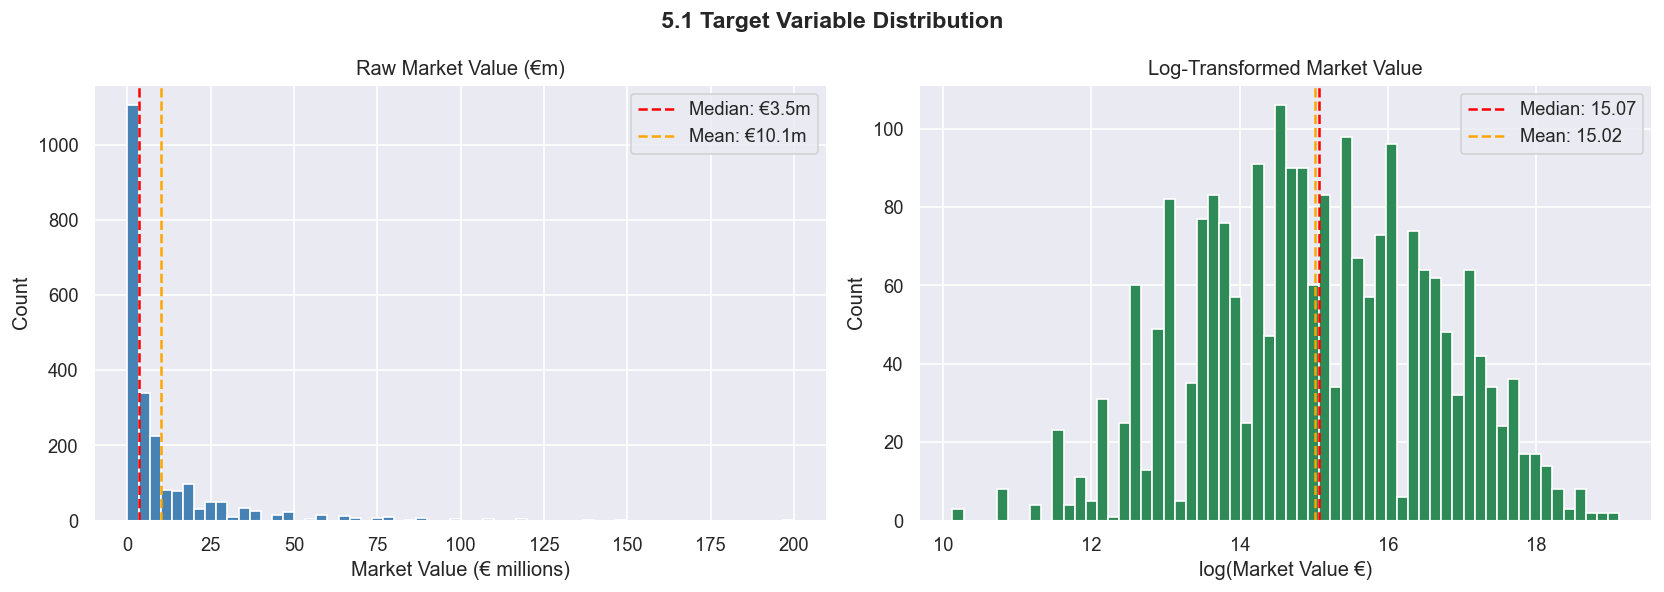

Skewness (raw): 4.08
Skewness (log): -0.06


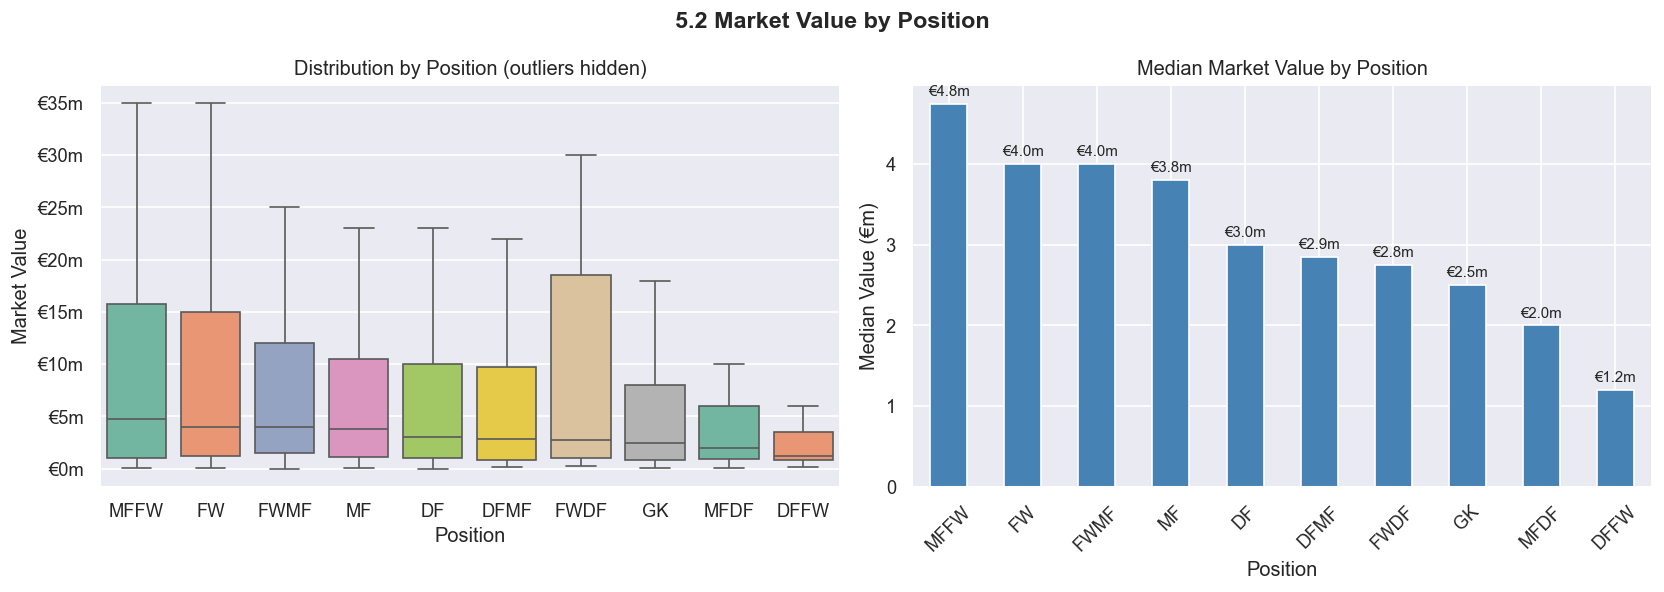

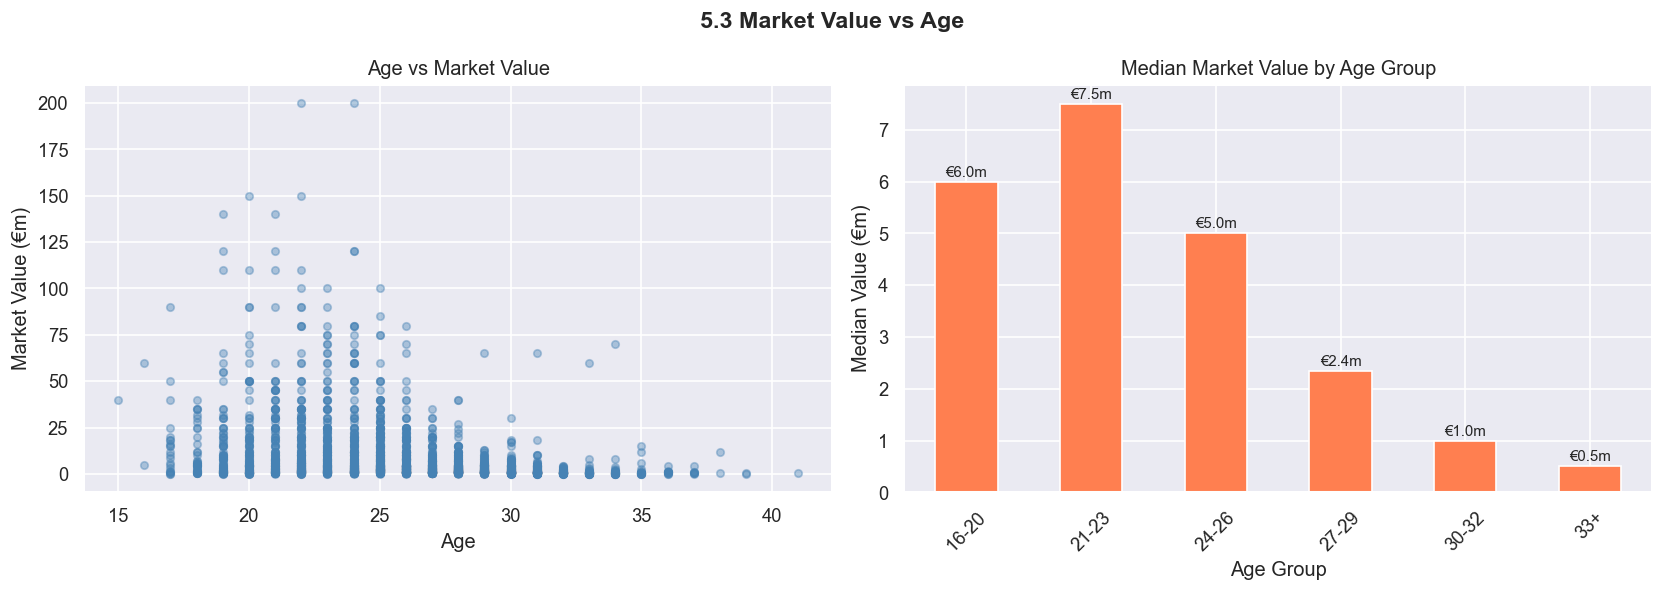

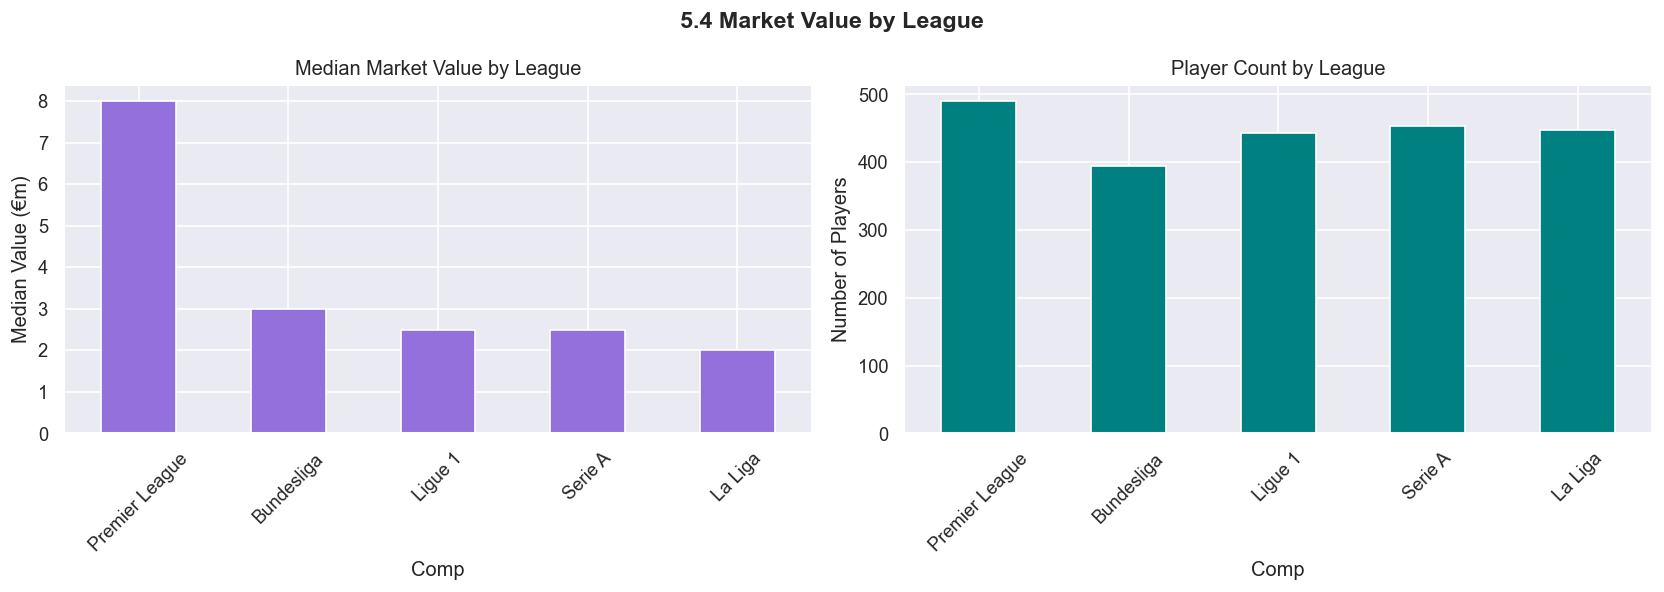

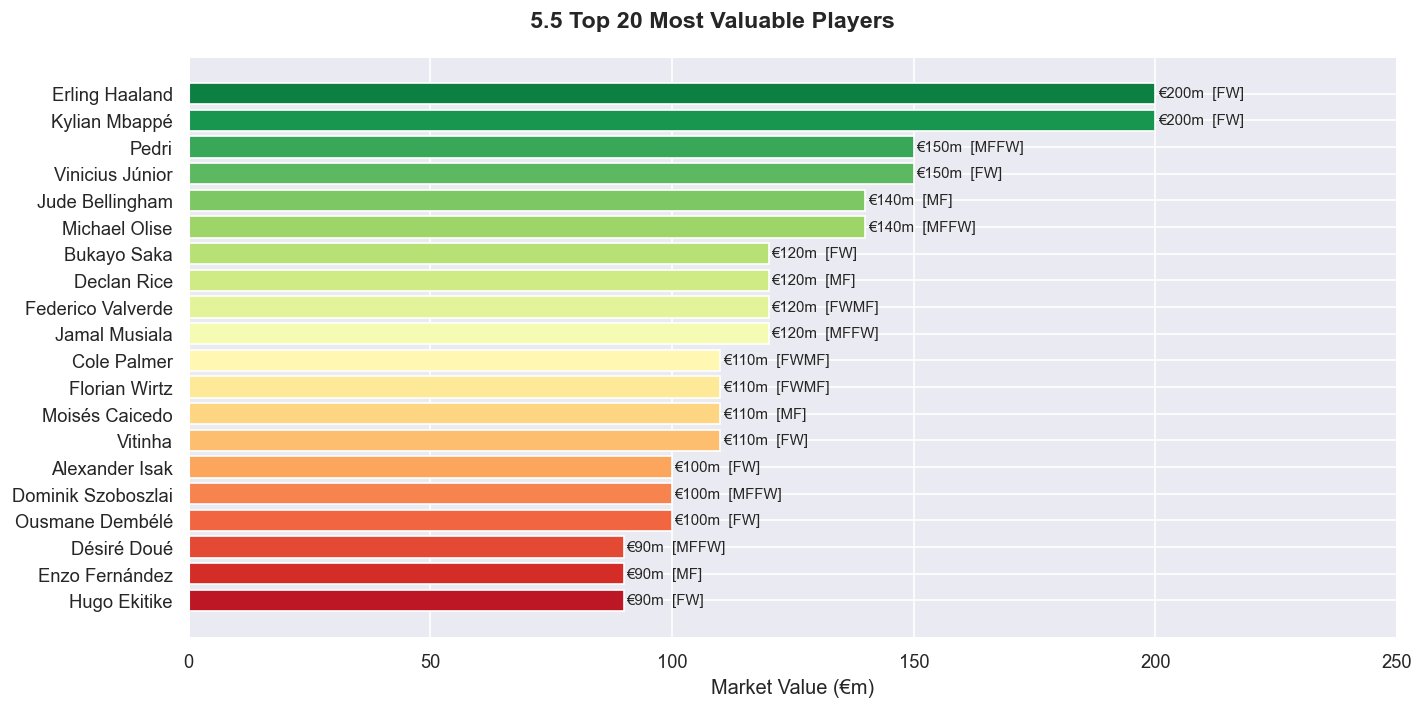

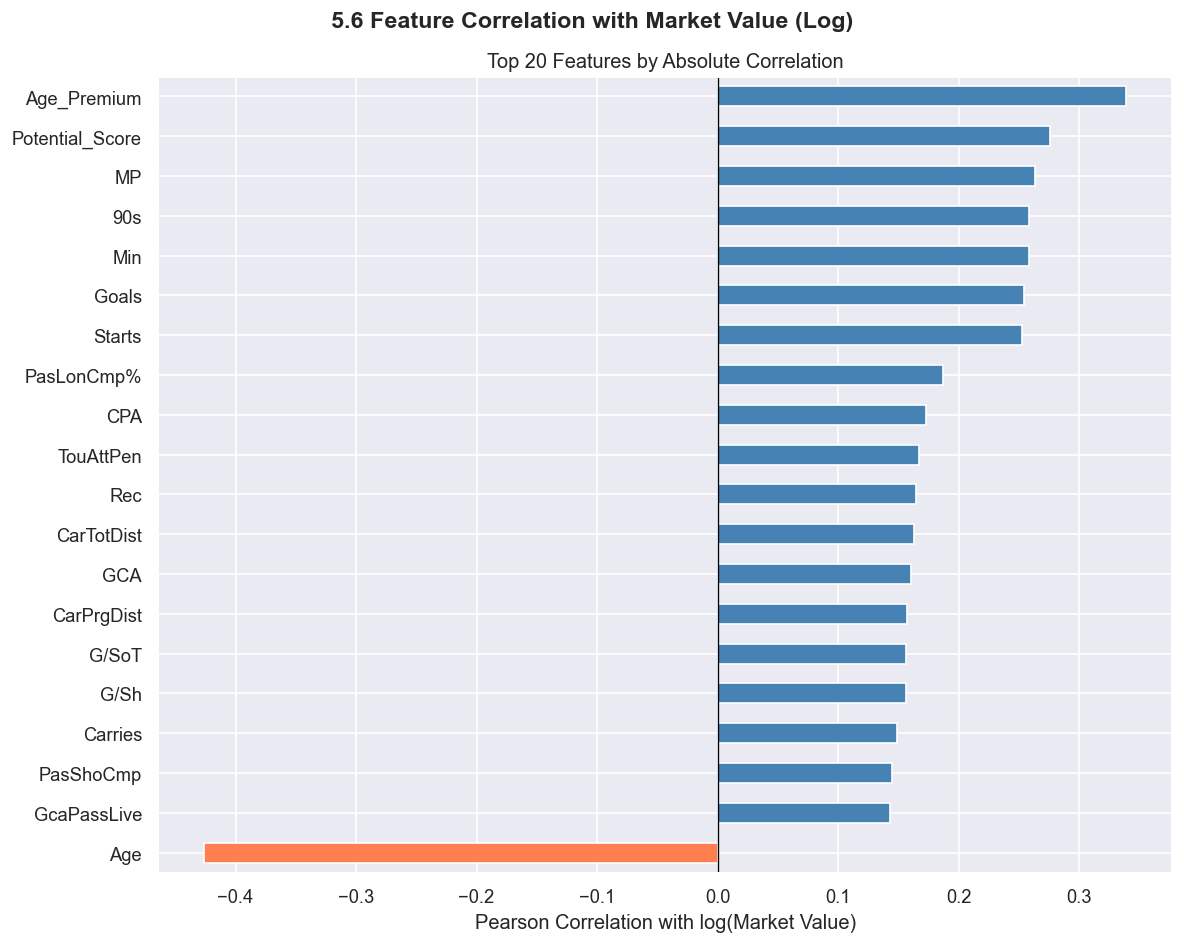


Top 20 correlated features:
Age_Premium        0.338938
Potential_Score    0.275762
MP                 0.263175
90s                0.258044
Min                0.258044
Goals              0.253933
Starts             0.252259
PasLonCmp%         0.187242
CPA                0.173014
TouAttPen          0.167224
Rec                0.164748
CarTotDist         0.162595
GCA                0.160316
CarPrgDist         0.156880
G/Sh               0.156097
G/SoT              0.156097
Carries            0.148329
PasShoCmp          0.144327
GcaPassLive        0.142761
Age               -0.426193


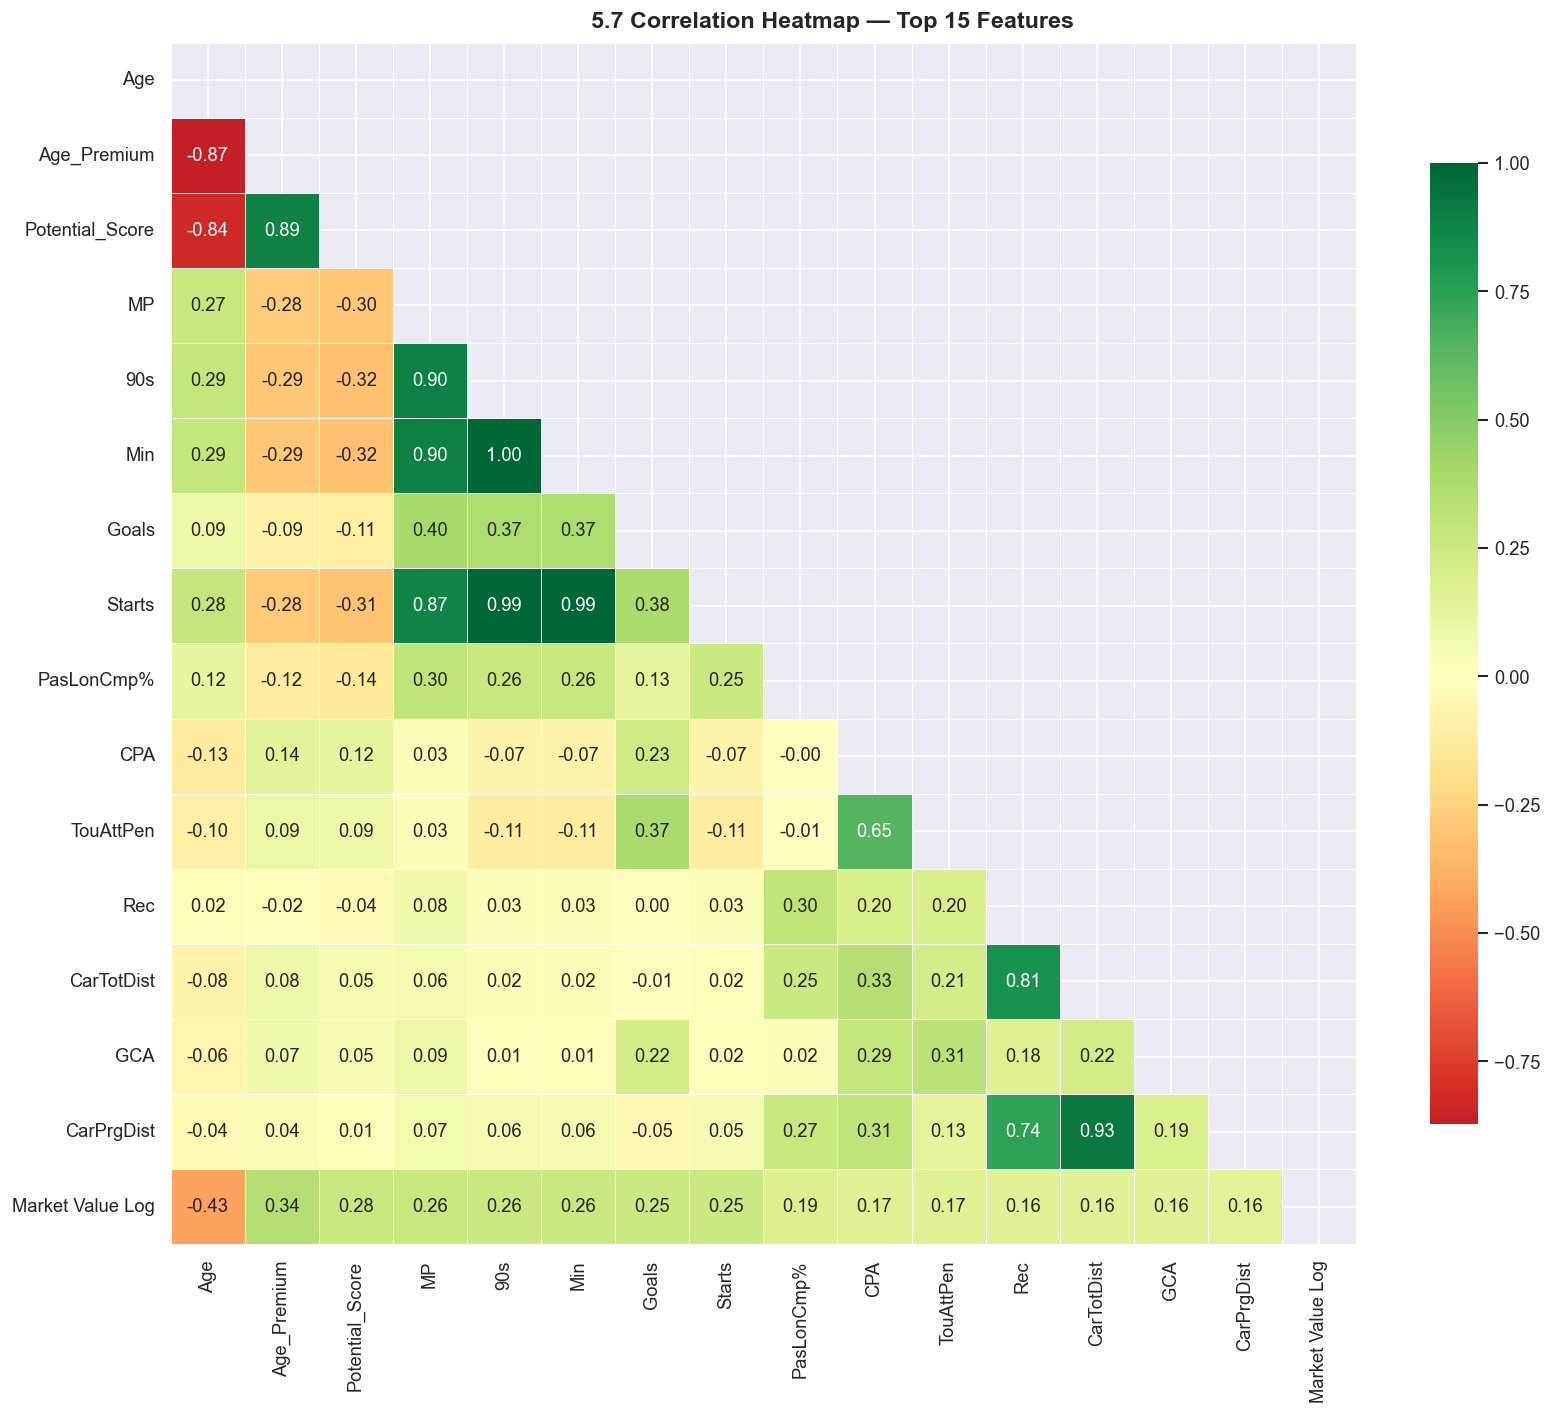

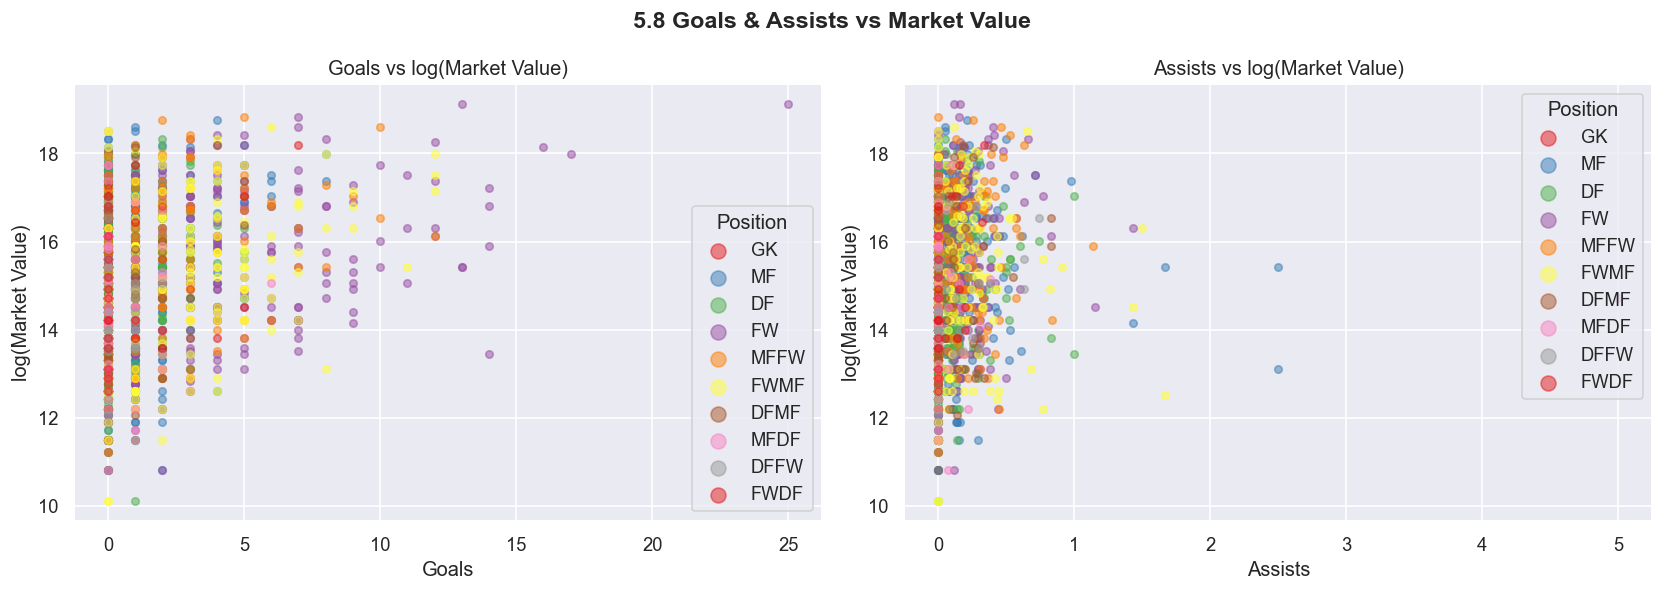

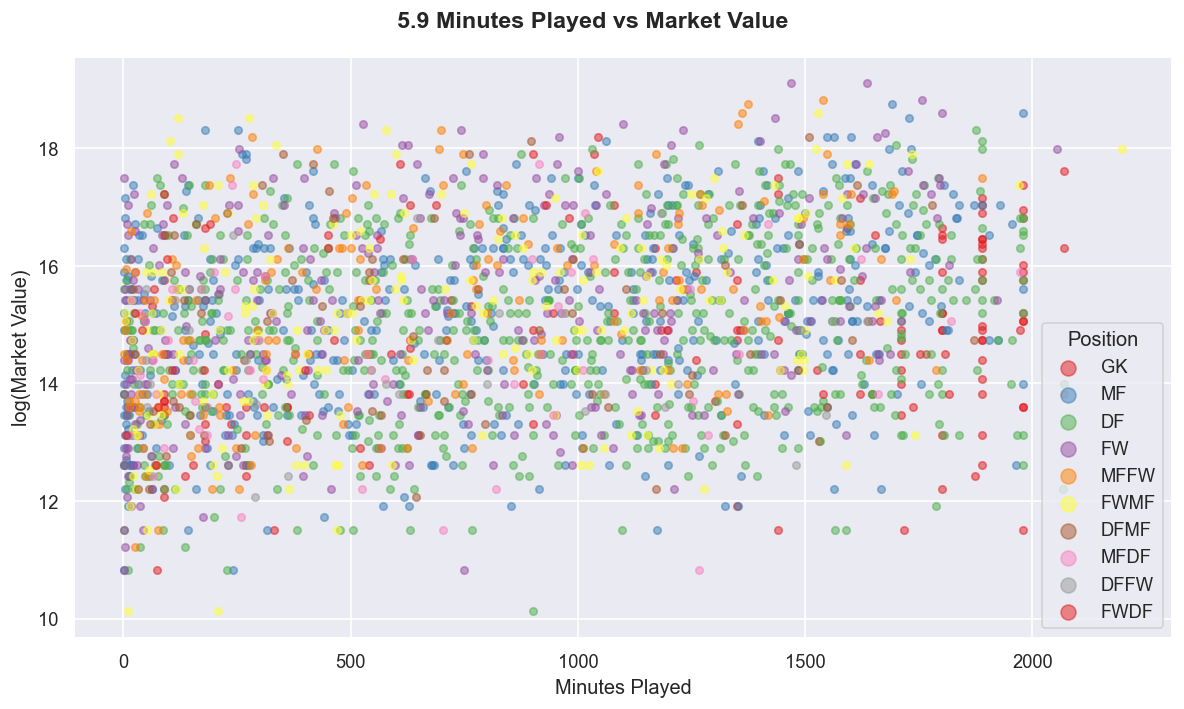


✅ All visualizations saved.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# =========================
# SETUP
# =========================

player_agg = pd.read_csv("preprocessed_dataset.csv")

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print(f"Dataset shape: {player_agg.shape}")
print(f"\nAll columns ({len(player_agg.columns)}):")
print(player_agg.columns.values)

# =========================
# 5.1 TARGET DISTRIBUTION
# Raw vs Log Transformed
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("5.1 Target Variable Distribution", fontsize=14, fontweight='bold')

# Raw
axes[0].hist(player_agg['Market Value Euros'] / 1e6, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title("Raw Market Value (€m)")
axes[0].set_xlabel("Market Value (€ millions)")
axes[0].set_ylabel("Count")
axes[0].axvline(player_agg['Market Value Euros'].median() / 1e6, color='red',
                linestyle='--', label=f"Median: €{player_agg['Market Value Euros'].median()/1e6:.1f}m")
axes[0].axvline(player_agg['Market Value Euros'].mean() / 1e6, color='orange',
                linestyle='--', label=f"Mean: €{player_agg['Market Value Euros'].mean()/1e6:.1f}m")
axes[0].legend()

# Log transformed
axes[1].hist(player_agg['Market Value Log'], bins=60, color='seagreen', edgecolor='white')
axes[1].set_title("Log-Transformed Market Value")
axes[1].set_xlabel("log(Market Value €)")
axes[1].set_ylabel("Count")
axes[1].axvline(player_agg['Market Value Log'].median(), color='red',
                linestyle='--', label=f"Median: {player_agg['Market Value Log'].median():.2f}")
axes[1].axvline(player_agg['Market Value Log'].mean(), color='orange',
                linestyle='--', label=f"Mean: {player_agg['Market Value Log'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("5.1_target_distribution.png")
plt.show()
print("Skewness (raw):", round(player_agg['Market Value Euros'].skew(), 2))
print("Skewness (log):", round(player_agg['Market Value Log'].skew(), 2))

# =========================
# 5.2 MARKET VALUE BY POSITION
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("5.2 Market Value by Position", fontsize=14, fontweight='bold')

pos_order = player_agg.groupby('Pos')['Market Value Euros'].median().sort_values(ascending=False).index

# Boxplot
sns.boxplot(data=player_agg, x='Pos', y='Market Value Euros',
            order=pos_order, ax=axes[0], palette='Set2', showfliers=False)
axes[0].set_title("Distribution by Position (outliers hidden)")
axes[0].set_xlabel("Position")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1e6:.0f}m'))
axes[0].set_ylabel("Market Value")

# Median bar chart
pos_median = player_agg.groupby('Pos')['Market Value Euros'].median().sort_values(ascending=False) / 1e6
pos_median.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title("Median Market Value by Position")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Median Value (€m)")
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(pos_median):
    axes[1].text(i, v + 0.1, f'€{v:.1f}m', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("5.2_value_by_position.png")
plt.show()

# =========================
# 5.3 MARKET VALUE BY AGE
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("5.3 Market Value vs Age", fontsize=14, fontweight='bold')

# Scatter
axes[0].scatter(player_agg['Age'], player_agg['Market Value Euros'] / 1e6,
                alpha=0.4, color='steelblue', s=20)
axes[0].set_title("Age vs Market Value")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Market Value (€m)")

# Age group medians
player_agg['Age Group'] = pd.cut(player_agg['Age'],
                                  bins=[15, 20, 23, 26, 29, 32, 40],
                                  labels=['16-20', '21-23', '24-26', '27-29', '30-32', '33+'])
age_median = player_agg.groupby('Age Group', observed=True)['Market Value Euros'].median() / 1e6
age_median.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title("Median Market Value by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Median Value (€m)")
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(age_median):
    axes[1].text(i, v + 0.1, f'€{v:.1f}m', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("5.3_value_by_age.png")
plt.show()

# =========================
# 5.4 MARKET VALUE BY LEAGUE
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("5.4 Market Value by League", fontsize=14, fontweight='bold')

league_median = player_agg.groupby('Comp')['Market Value Euros'].median().sort_values(ascending=False) / 1e6
league_count  = player_agg.groupby('Comp')['Player'].count().reindex(league_median.index)

# Median value
league_median.plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title("Median Market Value by League")
axes[0].set_ylabel("Median Value (€m)")
axes[0].tick_params(axis='x', rotation=45)

# Player count
league_count.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title("Player Count by League")
axes[1].set_ylabel("Number of Players")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("5.4_value_by_league.png")
plt.show()

# =========================
# 5.5 TOP 10 MOST VALUABLE PLAYERS
# =========================

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("5.5 Top 20 Most Valuable Players", fontsize=14, fontweight='bold')

top20 = player_agg.nlargest(20, 'Market Value Euros')[['Player', 'Pos', 'Market Value Euros']].copy()
top20['Market Value (€m)'] = top20['Market Value Euros'] / 1e6

colors = sns.color_palette("RdYlGn", 20)[::-1]
bars = ax.barh(top20['Player'], top20['Market Value (€m)'], color=colors, edgecolor='white')
ax.set_xlabel("Market Value (€m)")
ax.invert_yaxis()

for bar, (_, row) in zip(bars, top20.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"€{row['Market Value (€m)']:.0f}m  [{row['Pos']}]",
            va='center', fontsize=9)

ax.set_xlim(0, top20['Market Value (€m)'].max() * 1.25)
plt.tight_layout()
plt.savefig("5.5_top20_players.png")
plt.show()

# =========================
# 5.6 CORRELATION WITH MARKET VALUE
# Top 20 most correlated numeric features
# =========================

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("5.6 Feature Correlation with Market Value (Log)", fontsize=14, fontweight='bold')

numeric_cols = player_agg.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Market Value Euros', 'Market Value Log']]

correlations = player_agg[numeric_cols + ['Market Value Log']].corr()['Market Value Log'].drop('Market Value Log')
top_corr = correlations.abs().sort_values(ascending=False).head(20)
top_corr_vals = correlations[top_corr.index]

colors = ['steelblue' if v > 0 else 'coral' for v in top_corr_vals]
top_corr_vals.sort_values().plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Pearson Correlation with log(Market Value)")
ax.set_title("Top 20 Features by Absolute Correlation")

plt.tight_layout()
plt.savefig("5.6_feature_correlation.png")
plt.show()

print("\nTop 20 correlated features:")
print(top_corr_vals.sort_values(ascending=False).to_string())

# =========================
# 5.7 CORRELATION HEATMAP
# Top 15 features only (readable)
# =========================

top15_features = correlations.abs().sort_values(ascending=False).head(15).index.tolist()
corr_matrix = player_agg[top15_features + ['Market Value Log']].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle("5.7 Correlation Heatmap — Top 15 Features", fontsize=14, fontweight='bold')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, ax=ax,
            linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.tight_layout()
plt.savefig("5.7_correlation_heatmap.png")
plt.show()

# =========================
# 5.8 GOALS & ASSISTS vs MARKET VALUE
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("5.8 Goals & Assists vs Market Value", fontsize=14, fontweight='bold')

positions = player_agg['Pos'].unique()
palette   = sns.color_palette("Set1", len(positions))
pos_color = dict(zip(positions, palette))

for pos in positions:
    subset = player_agg[player_agg['Pos'] == pos]
    axes[0].scatter(subset['Goals'], subset['Market Value Log'],
                    alpha=0.5, label=pos, color=pos_color[pos], s=20)
    axes[1].scatter(subset['Assists'], subset['Market Value Log'],
                    alpha=0.5, label=pos, color=pos_color[pos], s=20)

axes[0].set_title("Goals vs log(Market Value)")
axes[0].set_xlabel("Goals")
axes[0].set_ylabel("log(Market Value)")
axes[0].legend(title='Position', markerscale=2)

axes[1].set_title("Assists vs log(Market Value)")
axes[1].set_xlabel("Assists")
axes[1].set_ylabel("log(Market Value)")
axes[1].legend(title='Position', markerscale=2)

plt.tight_layout()
plt.savefig("5.8_goals_assists_vs_value.png")
plt.show()

# =========================
# 5.9 MINUTES PLAYED vs MARKET VALUE
# =========================

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("5.9 Minutes Played vs Market Value", fontsize=14, fontweight='bold')

for pos in positions:
    subset = player_agg[player_agg['Pos'] == pos]
    ax.scatter(subset['Min'], subset['Market Value Log'],
               alpha=0.5, label=pos, color=pos_color[pos], s=20)

ax.set_xlabel("Minutes Played")
ax.set_ylabel("log(Market Value)")
ax.legend(title='Position', markerscale=2)

plt.tight_layout()
plt.savefig("5.9_minutes_vs_value.png")
plt.show()

print("\n✅ All visualizations saved.")

Loaded dataset: (2228, 135)

Creating advanced football economics features...

Advanced feature engineering completed.

New Features Added:
✓ Goals_per90
✓ Assists_per90
✓ GoalContributions_per90
✓ Age_Premium
✓ Potential_Score
✓ League_Strength
✓ Elite_Club_Boost
✓ Creative_Influence
✓ Goals_x_Age
✓ Superstar_Index
✓ Elite_Market_Signal
✓ Superstar_Escalation
✓ Clutch_Score
✓ Position_Adjusted_Score
Features after encoding: 357

X shape: (2228, 357)
y shape: (2228,)
y range: 10.13 → 19.11 (log scale)

--- Running Random Forest for Feature Importance ---
Random Forest R² (train): 0.8500

Top 20 Features:
               Variable  Feature Importance Score
                    Age                  0.261881
                    Min                  0.059506
                    90s                  0.054700
        League_Strength                  0.029414
       Elite_Club_Boost                  0.028415
    Comp_Premier League                  0.027802
                    Rec               

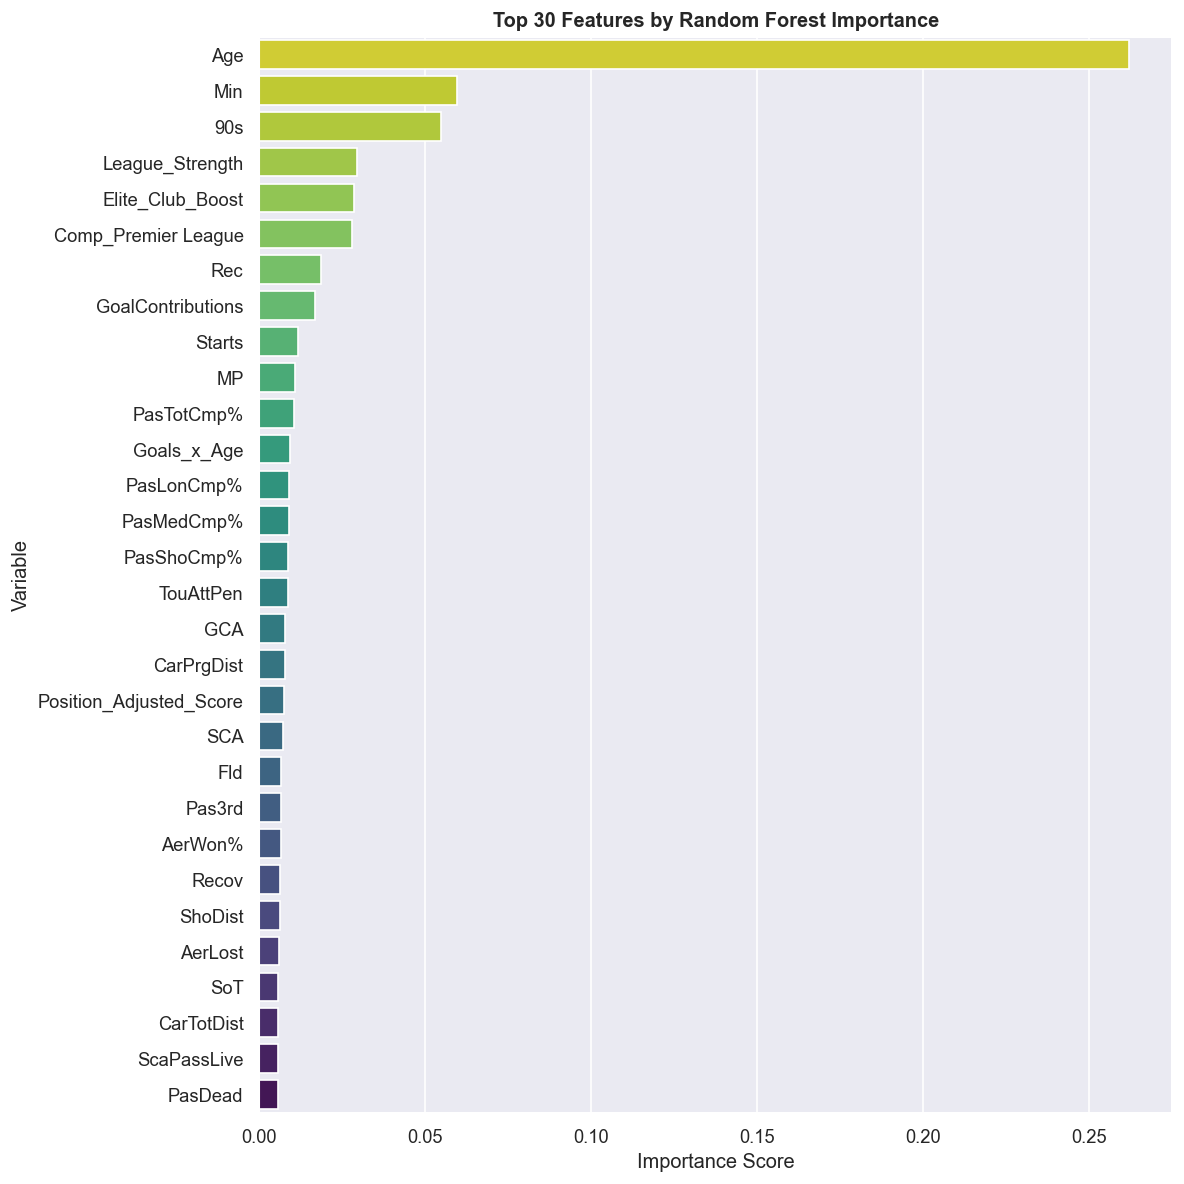


Mean importance threshold: 0.00280
Features selected: 91
['Age', 'Min', '90s', 'League_Strength', 'Elite_Club_Boost', 'Comp_Premier League', 'Rec', 'GoalContributions', 'Starts', 'MP', 'PasTotCmp%', 'Goals_x_Age', 'PasLonCmp%', 'PasMedCmp%', 'PasShoCmp%', 'TouAttPen', 'GCA', 'CarPrgDist', 'Position_Adjusted_Score', 'SCA', 'Fld', 'Pas3rd', 'AerWon%', 'Recov', 'ShoDist', 'AerLost', 'SoT', 'CarTotDist', 'ScaPassLive', 'PasDead', 'ScaDrib', 'Tkl_per90', 'TouMid3rd', 'ToTkl%', 'Youth_Premium', 'ScaSh', 'Carries', 'CarProg', 'Fls', 'PasTotPrgDist', 'Superstar_Escalation', 'TouAtt3rd', 'PasFK', 'PasTotDist', 'CPA', 'Elite_Market_Signal', 'TouDefPen', 'TB', 'GcaPassLive', 'Clr', 'AerWon', 'Age_Premium', 'CrdY', 'PasLonCmp', 'ToSuc%', 'Carries_per90', 'PasOff', 'CarDis', 'PasProg_per90', 'Blocks', 'Int_per90', 'BlkPass', 'TklDriPast', 'TouDef3rd', 'TklDriAtt', 'PasLive', 'PasShoCmp', 'PasProg', 'PasShoAtt', 'TklDri%', 'Creative_Influence', 'ToAtt', 'Sw', 'PasLonAtt', 'PasAss', 'BlkSh', 'SCA_pe

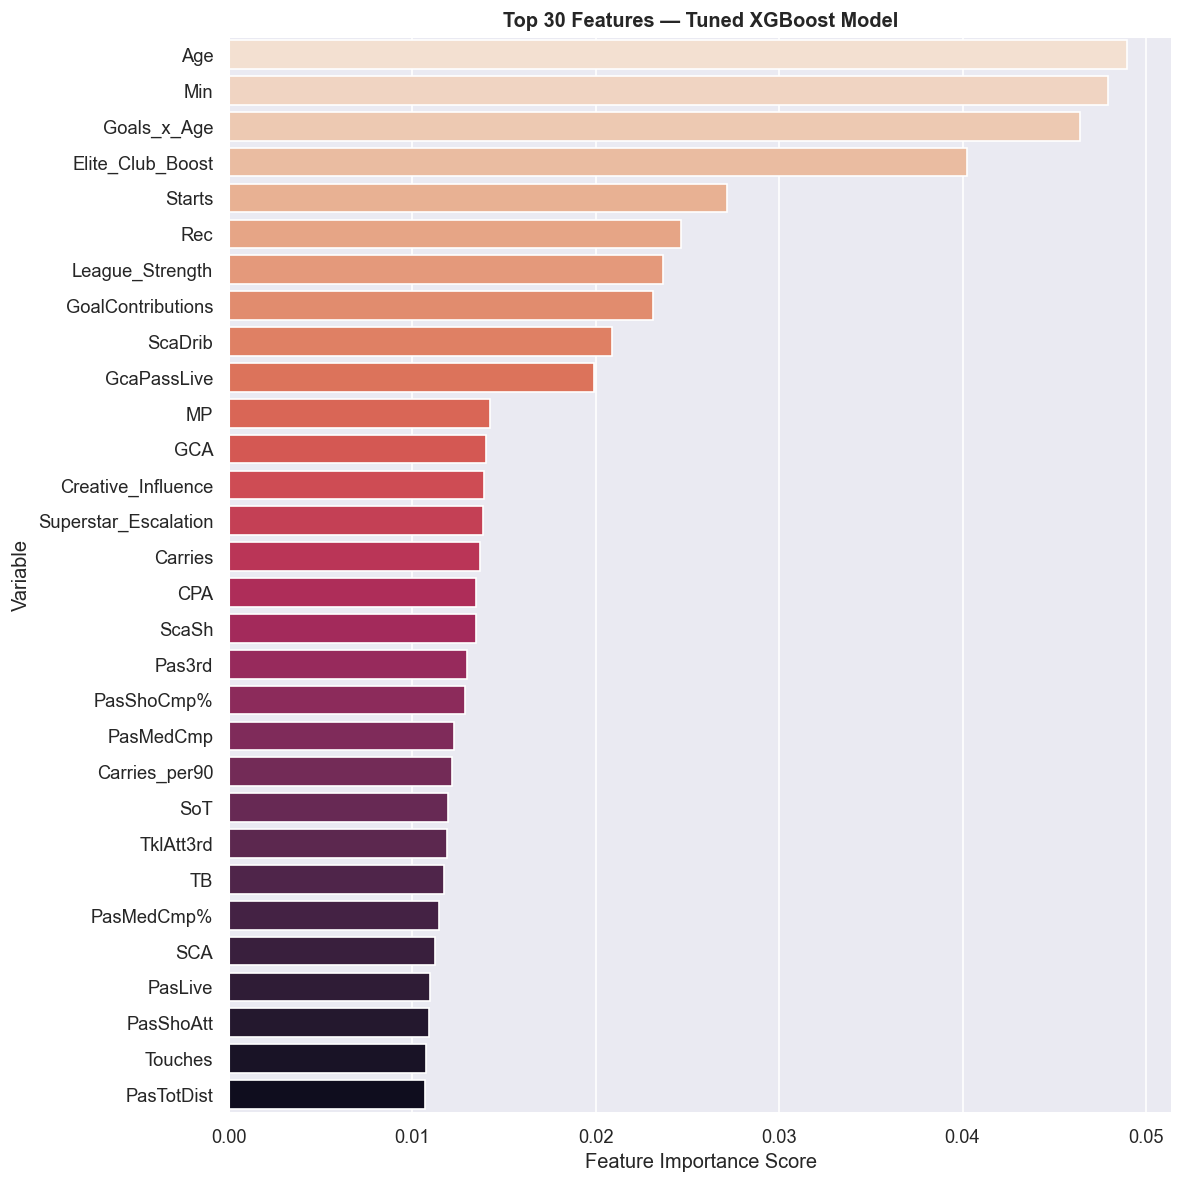

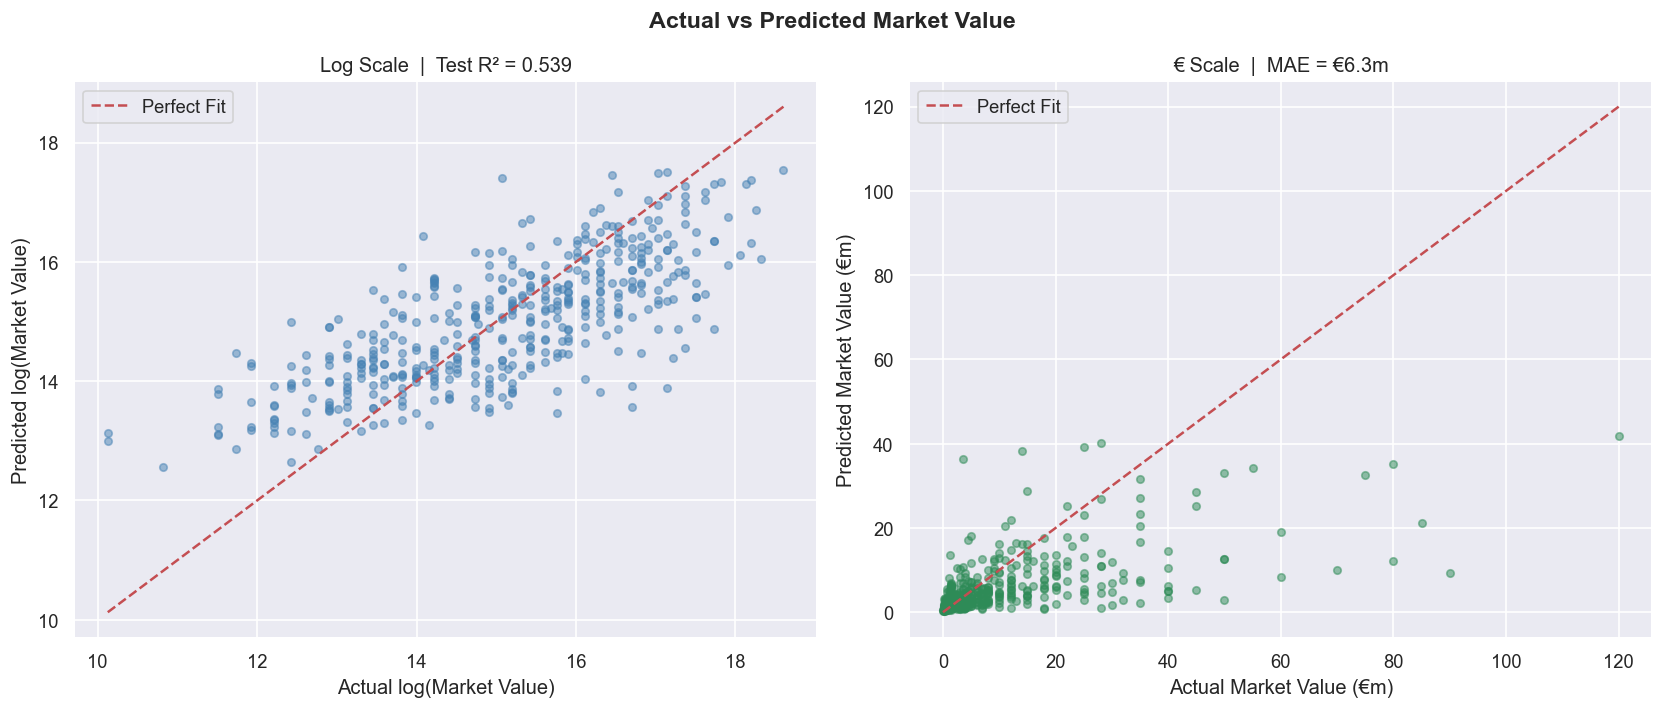

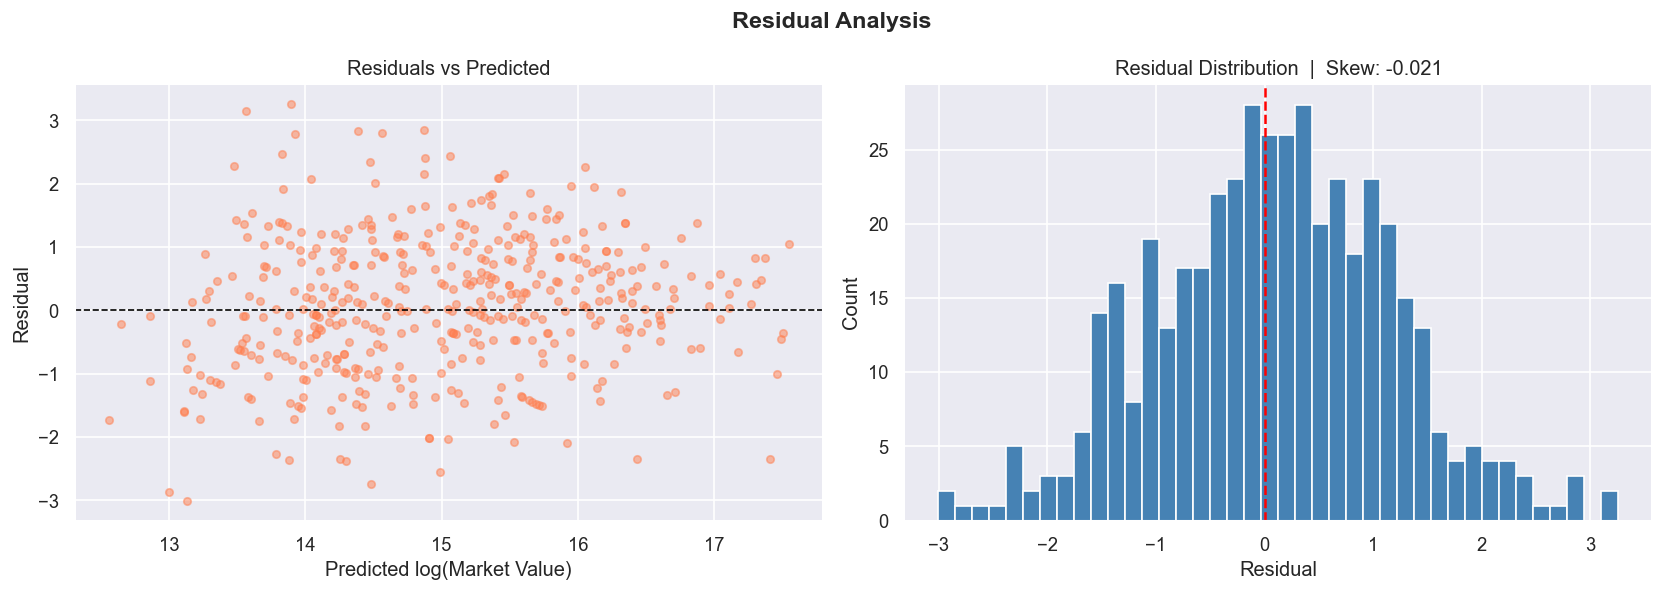


Model saved → xgb_final_model.pkl ✅
Feature importances saved → feature_importance.xlsx ✅
Final dataset saved → player_data_with_predictions.xlsx ✅

Top 10 Most Valuable Players — Predictions:
           Player  Pos Actual Market Value Predicted Market Value Error (%)
   Erling Haaland   FW             €200.0m                 €83.0m    -58.5%
    Kylian Mbappé   FW             €200.0m                 €42.6m    -78.7%
  Vinicius Júnior   FW             €150.0m                 €77.9m    -48.0%
            Pedri MFFW             €150.0m                 €66.5m    -55.7%
    Michael Olise MFFW             €140.0m                 €40.3m    -71.2%
  Jude Bellingham   MF             €140.0m                 €74.1m    -47.0%
      Declan Rice   MF             €120.0m                 €36.8m    -69.4%
Federico Valverde FWMF             €120.0m                 €41.7m    -65.2%
      Bukayo Saka   FW             €120.0m                 €86.5m    -27.9%
    Jamal Musiala MFFW             €120.0m    

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

sns.set_theme(style="darkgrid")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# =========================
# 1. LOAD DATA
# =========================

player_agg = pd.read_csv("preprocessed_dataset.csv")
print(f"Loaded dataset: {player_agg.shape}")

# ==========================================
# FOOTBALL ECONOMICS FEATURE ENGINEERING
# ==========================================

print("\nCreating advanced football economics features...")

# ==========================================
# SAFETY FOR DIVISION
# ==========================================

player_agg['90s'] = player_agg['90s'].replace(0, 1)

# ==========================================
# PER 90 FEATURES
# ==========================================

per90_cols = [
    'Goals',
    'Assists',
    'Shots',
    'SoT',
    'SCA',
    'GCA',
    'PasProg',
    'Carries',
    'Tkl',
    'Int'
]

for col in per90_cols:

    if col in player_agg.columns:

        player_agg[f'{col}_per90'] = (
            player_agg[col] /
            player_agg['90s']
        )

# ==========================================
# GOAL CONTRIBUTIONS
# ==========================================

player_agg['GoalContributions'] = (
    player_agg['Goals'] +
    player_agg['Assists']
)

player_agg['GoalContributions_per90'] = (
    player_agg['GoalContributions'] /
    player_agg['90s']
)

# ==========================================
# AGE PREMIUM
# Football markets LOVE young elite players
# ==========================================

player_agg['Age_Premium'] = np.where(

    player_agg['Age'] <= 21,
    2.0,

    np.where(
        player_agg['Age'] <= 24,
        1.5,

        np.where(
            player_agg['Age'] <= 28,
            1.15,
            0.85
        )
    )
)

# ==========================================
# POTENTIAL SCORE
# ==========================================

player_agg['Potential_Score'] = np.where(

    player_agg['Age'] <= 21,
    10,

    np.where(
        player_agg['Age'] <= 24,
        7,
        4
    )
)

# ==========================================
# LEAGUE STRENGTH
# ==========================================

league_strength_map = {

    'Premier League': 1.35,
    'La Liga': 1.30,
    'Bundesliga': 1.25,
    'Serie A': 1.20,
    'Ligue 1': 1.15,

    # fallback
}

player_agg['League_Strength'] = (
    player_agg['Comp']
    .map(league_strength_map)
    .fillna(1.0)
)

# ==========================================
# ELITE CLUB BOOST
# ==========================================

elite_clubs = [

    'Manchester City',
    'Real Madrid',
    'Barcelona',
    'Bayern Munich',
    'Liverpool',
    'Arsenal',
    'PSG',
    'Chelsea',
    'Manchester United'
]

player_agg['Elite_Club_Boost'] = np.where(
    player_agg['Squad'].isin(elite_clubs),
    1,
    0
)

# ==========================================
# ATTACKER PREMIUM
# ==========================================

player_agg['Attacker_Premium'] = np.where(

    player_agg['Pos'].str.contains(
        'FW',
        na=False
    ),

    1.25,

    1.0
)

# ==========================================
# CREATIVE INFLUENCE
# ==========================================

player_agg['Creative_Influence'] = (

    player_agg.get('SCA_per90', 0) * 0.4 +

    player_agg.get('PasProg_per90', 0) * 0.35 +

    player_agg.get('Carries_per90', 0) * 0.25
)

# ==========================================
# GOALS x AGE INTERACTION
# ==========================================

player_agg['Goals_x_Age'] = (

    player_agg.get('Goals_per90', 0) *

    (30 - player_agg['Age'])
)

# ==========================================
# ASSISTS x YOUTH
# ==========================================

player_agg['Assists_x_Youth'] = (

    player_agg.get('Assists_per90', 0) *

    player_agg['Age_Premium']
)

# ==========================================
# SUPERSTAR INDEX
# THIS IS MASSIVE
# ==========================================

player_agg['Superstar_Index'] = (

    player_agg.get('Goals_per90', 0) * 0.30 +

    player_agg.get('Assists_per90', 0) * 0.20 +

    player_agg.get('SCA_per90', 0) * 0.20 +

    player_agg.get('GCA_per90', 0) * 0.15 +

    player_agg.get('PasProg_per90', 0) * 0.10 +

    player_agg.get('Carries_per90', 0) * 0.05
)

# ==========================================
# ELITE MARKET SIGNAL
# MOST IMPORTANT FEATURE
# ==========================================

player_agg['Elite_Market_Signal'] = (

    player_agg['Superstar_Index'] *

    player_agg['Age_Premium'] *

    player_agg['League_Strength']
)

# ==========================================
# SUPERSTAR ESCALATION
# NONLINEAR FOOTBALL ECONOMICS
# ==========================================

player_agg['Superstar_Escalation'] = np.where(

    player_agg['Elite_Market_Signal'] > 1.5,

    player_agg['Elite_Market_Signal'] * 1.8,

    player_agg['Elite_Market_Signal']
)

# ==========================================
# CLUTCH SCORE
# ==========================================

player_agg['Clutch_Score'] = (

    player_agg.get('Goals_per90', 0) * 0.5 +

    player_agg.get('GCA_per90', 0) * 0.3 +

    player_agg.get('SCA_per90', 0) * 0.2
)

# ==========================================
# xG OVERPERFORMANCE
# ==========================================

if 'xG' in player_agg.columns:

    player_agg['xG_Overperformance'] = (

        player_agg['Goals'] -

        player_agg['xG']
    )

# ==========================================
# POSITION-ADJUSTED SCORE
# ==========================================

player_agg['Position_Adjusted_Score'] = np.where(

    player_agg['Pos'].str.contains('FW', na=False),

    (
        player_agg.get('Goals_per90', 0) * 0.5 +

        player_agg.get('Assists_per90', 0) * 0.25 +

        player_agg.get('SCA_per90', 0) * 0.25
    ),

    (
        player_agg.get('Tkl_per90', 0) * 0.3 +

        player_agg.get('Int_per90', 0) * 0.3 +

        player_agg.get('PasProg_per90', 0) * 0.2 +

        player_agg.get('Carries_per90', 0) * 0.2
    )
)

# ==========================================
# YOUTH PREMIUM
# ==========================================

player_agg['Youth_Premium'] = np.where(
    player_agg['Age'] <= 25,
    1,
    0
)

# ==========================================
# FINAL CHECK
# ==========================================

print("\nAdvanced feature engineering completed.")

print("\nNew Features Added:")

new_features = [

    'Goals_per90',
    'Assists_per90',
    'GoalContributions_per90',
    'Age_Premium',
    'Potential_Score',
    'League_Strength',
    'Elite_Club_Boost',
    'Creative_Influence',
    'Goals_x_Age',
    'Superstar_Index',
    'Elite_Market_Signal',
    'Superstar_Escalation',
    'Clutch_Score',
    'Position_Adjusted_Score'
]

for feat in new_features:

    if feat in player_agg.columns:
        print(f"✓ {feat}")

# =========================
# 2. ENCODE CATEGORICAL FEATURES
# =========================

# One-hot encode Pos, Nation, Squad, Comp
cat_cols = ['Pos', 'Nation', 'Squad', 'Comp']
player_encoded = pd.get_dummies(player_agg, columns=cat_cols, drop_first=False)

# Drop columns not used for modelling
drop_cols = ['Player', 'Market Value', 'Age Group',
             'Market Value Euros', 'Market Value Log']
drop_cols = [c for c in drop_cols if c in player_encoded.columns]

feature_cols = [c for c in player_encoded.columns if c not in drop_cols]

print(f"Features after encoding: {len(feature_cols)}")

# =========================
# 3. SPLIT X & y
# Use LOG-transformed target to fix skew
# =========================

X = player_encoded[feature_cols]
y = player_encoded['Market Value Log']          # ← log scale
y_raw = player_encoded['Market Value Euros']    # keep raw for final output

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y range: {y.min():.2f} → {y.max():.2f} (log scale)")

# =========================
# 4. FEATURE IMPORTANCE
# Using RandomForestRegressor (correct for regression)
# DecisionTreeClassifier in reference code was WRONG
# =========================

print("\n--- Running Random Forest for Feature Importance ---")

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=15,
    n_jobs=-1
)
rf.fit(X, y)
print(f"Random Forest R² (train): {rf.score(X, y):.4f}")

# Build feature importance dataframe
fi_df = pd.DataFrame({
    'Variable': X.columns,
    'Feature Importance Score': rf.feature_importances_
}).sort_values('Feature Importance Score', ascending=False).reset_index(drop=True)

print(f"\nTop 20 Features:")
print(fi_df.head(20).to_string(index=False))

# --- Plot top 30 ---
fig, ax = plt.subplots(figsize=(10, 10))
top30 = fi_df.head(30)
sns.barplot(data=top30, x='Feature Importance Score', y='Variable',
            palette='viridis_r', ax=ax)
ax.set_title("Top 30 Features by Random Forest Importance", fontweight='bold')
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("6.1_feature_importance.png")
plt.show()

# =========================
# 5. FEATURE SELECTION
# Keep features with importance > mean importance
# This gives ~30-50 meaningful features
# =========================

mean_importance = fi_df['Feature Importance Score'].mean()
selected_features = fi_df[fi_df['Feature Importance Score'] > mean_importance]['Variable'].tolist()

print(f"\nMean importance threshold: {mean_importance:.5f}")
print(f"Features selected: {len(selected_features)}")
print(selected_features)

X_selected = X[selected_features]

# =========================
# 6. TRAIN / TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")

# =========================
# 7. BASELINE XGBOOST
# =========================

print("\n--- Baseline XGBoost ---")

xgb_base = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)
xgb_base.fit(X_train, y_train)

y_pred_base = xgb_base.predict(X_test)

print(f"Train R²:  {xgb_base.score(X_train, y_train):.4f}")
print(f"Test  R²:  {r2_score(y_test, y_pred_base):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_base)):.4f} (log scale)")

# =========================
# 8. HYPERPARAMETER TUNING
# =========================

print("\n--- Hyperparameter Tuning (RandomizedSearchCV) ---")

param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'max_depth':         [3, 4, 5, 6],
    'subsample':         [0.7, 0.8, 1.0],
    'colsample_bytree':  [0.7, 0.8, 1.0],
    'gamma':             [0, 0.1, 0.2, 0.3],
    'min_child_weight':  [1, 3, 5],
    'reg_alpha':         [0, 0.1, 0.5],     # L1 — helps reduce overfitting
    'reg_lambda':        [1, 1.5, 2.0],     # L2 — helps reduce overfitting
}

xgb_tune = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_dist,
    scoring='neg_root_mean_squared_error',
    n_iter=40,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_params = random_search.best_params_
print(f"\nBest Parameters: {best_params}")

# =========================
# 9. EVALUATE TUNED MODEL
# =========================

best_model = random_search.best_estimator_

y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)
y_pred_all   = best_model.predict(X_selected)

r2_train  = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test,  y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
mae_test   = mean_absolute_error(y_test, y_pred_test)

print("\n" + "="*45)
print("          TUNED MODEL RESULTS")
print("="*45)
print(f"  Train R²:        {r2_train:.4f}")
print(f"  Test  R²:        {r2_test:.4f}")
print(f"  Train RMSE:      {rmse_train:.4f} (log)")
print(f"  Test  RMSE:      {rmse_test:.4f} (log)")
print(f"  Test  MAE:       {mae_test:.4f} (log)")

# Overfit check
overfit_gap = r2_train - r2_test
print(f"\n  Overfit gap:     {overfit_gap:.4f}  ", end="")
if overfit_gap < 0.1:
    print("✅ Healthy")
elif overfit_gap < 0.2:
    print("⚠️  Mild overfitting")
else:
    print("🚨 Significant overfitting — consider more regularization")

# Convert log predictions back to euros for interpretability
y_pred_euros = np.expm1(y_pred_test)
y_test_euros = np.expm1(y_test)
mae_euros    = mean_absolute_error(y_test_euros, y_pred_euros)
print(f"\n  Test MAE (€):    €{mae_euros:,.0f}")

# 5-fold cross validation
cv_scores = cross_val_score(best_model, X_selected, y, cv=5, scoring='r2', n_jobs=-1)
print(f"\n  5-Fold CV R²:    {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("="*45)

# =========================
# 10. FEATURE IMPORTANCE (TUNED MODEL)
# =========================

xgb_fi_df = pd.DataFrame({
    'Variable': X_selected.columns,
    'Feature Importance Score': best_model.feature_importances_
}).sort_values('Feature Importance Score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 10))
top30_xgb = xgb_fi_df.head(30)
sns.barplot(data=top30_xgb, x='Feature Importance Score', y='Variable',
            palette='rocket_r', ax=ax)
ax.set_title("Top 30 Features — Tuned XGBoost Model", fontweight='bold')
plt.tight_layout()
plt.savefig("6.2_xgb_feature_importance.png")
plt.show()

# =========================
# 11. ACTUAL vs PREDICTED PLOT
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Actual vs Predicted Market Value", fontsize=14, fontweight='bold')

# Log scale
axes[0].scatter(y_test, y_pred_test, alpha=0.5, color='steelblue', s=20)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=1.5, label='Perfect Fit')
axes[0].set_xlabel("Actual log(Market Value)")
axes[0].set_ylabel("Predicted log(Market Value)")
axes[0].set_title(f"Log Scale  |  Test R² = {r2_test:.3f}")
axes[0].legend()

# Euro scale
axes[1].scatter(y_test_euros / 1e6, y_pred_euros / 1e6, alpha=0.5, color='seagreen', s=20)
axes[1].plot([0, y_test_euros.max() / 1e6],
             [0, y_test_euros.max() / 1e6], 'r--', linewidth=1.5, label='Perfect Fit')
axes[1].set_xlabel("Actual Market Value (€m)")
axes[1].set_ylabel("Predicted Market Value (€m)")
axes[1].set_title(f"€ Scale  |  MAE = €{mae_euros/1e6:.1f}m")
axes[1].legend()

plt.tight_layout()
plt.savefig("6.3_actual_vs_predicted.png")
plt.show()

# =========================
# 12. RESIDUAL PLOT
# =========================

residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Residual Analysis", fontsize=14, fontweight='bold')

axes[0].scatter(y_pred_test, residuals, alpha=0.5, color='coral', s=20)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel("Predicted log(Market Value)")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual Distribution  |  Skew: {residuals.skew():.3f}")

plt.tight_layout()
plt.savefig("6.4_residuals.png")
plt.show()

# =========================
# 13. SAVE MODEL & RESULTS
# =========================

# Save model
with open("xgb_final_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
print("\nModel saved → xgb_final_model.pkl ✅")

# Save feature importances
xgb_fi_df.to_excel("feature_importance.xlsx", index=False)
print("Feature importances saved → feature_importance.xlsx ✅")

# Add predictions to full dataset
player_agg_out = player_agg.copy()
player_agg_out['Predicted Log Value']    = y_pred_all
player_agg_out['Predicted Market Value'] = np.expm1(y_pred_all).round(0)
player_agg_out['Actual Market Value']    = player_agg_out['Market Value Euros']
player_agg_out['Error (€)']             = (
    player_agg_out['Predicted Market Value'] - player_agg_out['Actual Market Value']
)
player_agg_out['Error (%)'] = (
    player_agg_out['Error (€)'] / player_agg_out['Actual Market Value'] * 100
).round(2)

# Sort by actual value descending
player_agg_out = player_agg_out.sort_values('Actual Market Value', ascending=False)

player_agg_out.to_excel("player_data_with_predictions.xlsx", index=False)
print("Final dataset saved → player_data_with_predictions.xlsx ✅")

# Quick preview — top 10 most valuable with predictions
preview_cols = ['Player', 'Pos', 'Actual Market Value', 'Predicted Market Value', 'Error (%)']
preview = player_agg_out[preview_cols].head(10).copy()
preview['Actual Market Value']    = preview['Actual Market Value'].apply(lambda x: f"€{x/1e6:.1f}m")
preview['Predicted Market Value'] = preview['Predicted Market Value'].apply(lambda x: f"€{x/1e6:.1f}m")
preview['Error (%)']              = preview['Error (%)'].apply(lambda x: f"{x:+.1f}%")
print(f"\nTop 10 Most Valuable Players — Predictions:")
print(preview.to_string(index=False))